# CO Climate Assessment - Binning of Climate Data Colorbars

This notebook builds on the [colormap notebook](climate_hazard_colormaps.ipynb), to render the symbology for all potential climate hazard variables into a limited number of bins, to meet the limitations of the Esri tool used for the web visualizer.

*Note:* This present notebook simply parses the `symbology_specifications.tsv` file, and does not take into account the true min and max values of the actual data for each climate hazard. This might mean that for diverging colormaps (i.e., those that must preserve symmetry about zero) used for variables where most if not all values skew towards a single side, a lower effective number of bins are used to classify the values actually present, and several bins will have no values present in the data. If this presents an issue, contact JT and they can add some additional scripting to account for this.

In [1]:
import json
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import requests
import fsspec

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean

In [2]:
#####################################
# Copy this code block to use these #
# colormaps in your own scripts!    #
# (with corresponding imports)      #
#####################################

# Fetch the custom colormaps
colormap_url = (
    "https://raw.githubusercontent.com/jthielen/co_climate_hazard_maps/refs/heads/main/"
    "custom_colormaps.json"
)
try:
    r = requests.get(colormap_url)
    r.raise_for_status()
    color_data = r.json()
except Exception as e:
    print(f"Could not access colormap reference - {e}")

# Register them with matplotlib
for var_name, this_var in color_data['colormaps'].items():
    lutsize = mpl.rcParams['image.lut'] if this_var["quantization_levels"] == "LUT" else this_var["quantization_levels"]
    cmap = colors.LinearSegmentedColormap.from_list(var_name, this_var["color_list"], lutsize)
    cmap_reversed = colors.LinearSegmentedColormap.from_list(var_name + "_r", this_var["color_list"][::-1], lutsize)
    mpl.colormaps.register(name=var_name, cmap=cmap, force=True)
    mpl.colormaps.register(name=var_name + "_r", cmap=cmap_reversed, force=True)

In [3]:
symbology_specs_url = (
    "https://raw.githubusercontent.com/jthielen/co_climate_hazard_maps/refs/heads/main/"
    "symbology_specifications.tsv"
)
try:
    symbology_table = pd.read_csv(symbology_specs_url, sep="\t")
except Exception as e:
    print(f"Could not access hazard symbology reference - {e}")

agg_20th_pct_change

For ['GWL_1.1', 'GWL_1.5', 'GWL_2.0', 'GWL_2.5'], use:

Bin divisions: [0.000, 25.000, 50.000, 75.000, 100.000, 125.000, 150.000, 175.000, 200.000, 225.000, 250.000]
Bin centers: [12.500, 37.500, 62.500, 87.500, 112.500, 137.500, 162.500, 187.500, 212.500, 237.500]
Colors: ["#EBDFDC", "#E0C0B6", "#D7A291", "#CF866D", "#C5684A", "#BA492F", "#AA2724", "#8E1029", "#6D0E26", "#4B0C19"]


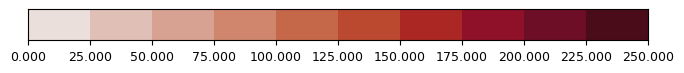




agg_5th_pct_change

For ['GWL_1.1', 'GWL_1.5', 'GWL_2.0', 'GWL_2.5'], use:

Bin divisions: [0.000, 80.000, 160.000, 240.000, 320.000, 400.000, 480.000, 560.000, 640.000, 720.000, 800.000]
Bin centers: [40.000, 120.000, 200.000, 280.000, 360.000, 440.000, 520.000, 600.000, 680.000, 760.000]
Colors: ["#EBDFDC", "#E0C0B6", "#D7A291", "#CF866D", "#C5684A", "#BA492F", "#AA2724", "#8E1029", "#6D0E26", "#4B0C19"]


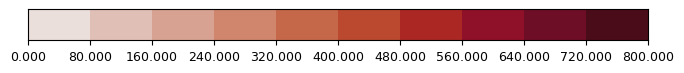




agg_95th_pct_change

For ['GWL_1.1', 'GWL_1.5', 'GWL_2.0', 'GWL_2.5'], use:

Bin divisions: [-100.000, -77.778, -55.556, -33.333, -11.111, 11.111, 33.333, 55.556, 77.778, 100.000]
Bin centers: [-88.889, -66.667, -44.444, -22.222, 0.000, 22.222, 44.444, 66.667, 88.889]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


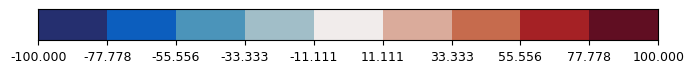




agg_SWEREF_20th

For [''], use:

Bin divisions: [0.000, 45.000, 90.000, 135.000, 180.000, 225.000, 270.000, 315.000, 360.000, 405.000, 450.000]
Bin centers: [22.500, 67.500, 112.500, 157.500, 202.500, 247.500, 292.500, 337.500, 382.500, 427.500]
Colors: ["#E5F4BE", "#AEE2A9", "#78CEA3", "#5AB6A4", "#4D9BA1", "#44829B", "#3E6896", "#404C8B", "#3E3666", "#30233D"]


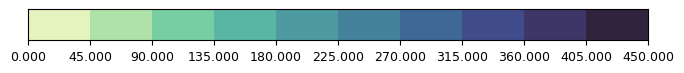




agg_SWEREF_5th

For [''], use:

Bin divisions: [0.000, 35.000, 70.000, 105.000, 140.000, 175.000, 210.000, 245.000, 280.000, 315.000, 350.000]
Bin centers: [17.500, 52.500, 87.500, 122.500, 157.500, 192.500, 227.500, 262.500, 297.500, 332.500]
Colors: ["#E5F4BE", "#AEE2A9", "#78CEA3", "#5AB6A4", "#4D9BA1", "#44829B", "#3E6896", "#404C8B", "#3E3666", "#30233D"]


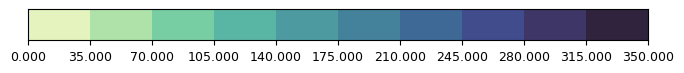




agg_SWEREF_95th

For [''], use:

Bin divisions: [0.000, 100.000, 200.000, 300.000, 400.000, 500.000, 600.000, 700.000, 800.000, 900.000, 1000.000]
Bin centers: [50.000, 150.000, 250.000, 350.000, 450.000, 550.000, 650.000, 750.000, 850.000, 950.000]
Colors: ["#E5F4BE", "#AEE2A9", "#78CEA3", "#5AB6A4", "#4D9BA1", "#44829B", "#3E6896", "#404C8B", "#3E3666", "#30233D"]


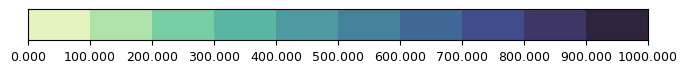




cv
==

For ['10m_GWL20C_SON_actual_values', '10m_GWL20C_DJF_actual_values', '10m_GWL20C_MAM_actual_values', '10m_GWL20C_JJA_actual_values', '10m_GWL20C_ANN_actual_values', '10m_GWL11C_SON_actual_values', '10m_GWL11C_DJF_actual_values', '10m_GWL11C_MAM_actual_values', '10m_GWL11C_JJA_actual_values', '10m_GWL11C_ANN_actual_values', '10m_GWL15C_SON_actual_values', '10m_GWL15C_DJF_actual_values', '10m_GWL15C_MAM_actual_values', '10m_GWL15C_JJA_actual_values', '10m_GWL15C_ANN_actual_values', '10m_hist_SON_actual_values', '10m_hist_DJF_actual_values', '10m_hist_MAM_actual_values', '10m_hist_JJA_actual_values', '10m_hist_ANN_actual_values', '10m_GWL25C_SON_actual_values', '10m_GWL25C_DJF_actual_values', '10m_GWL25C_MAM_actual_values', '10m_GWL25C_JJA_actual_values', '10m_GWL25C_ANN_actual_values', '100m_GWL25C_SON_actual_values', '100m_GWL25C_DJF_actual_values', '100m_GWL25C_MAM_actual_values', '100m_GWL25C_JJA_actual_values', '100m_GWL25C_ANN_actual_values', '100m_hist_SON_actual_values',

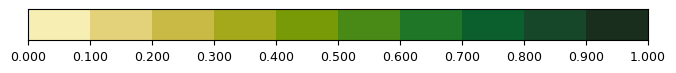


For ['GWL11C_ANN_absolute_change', 'GWL15C_ANN_absolute_change', 'GWL20C_ANN_absolute_change', 'GWL25C_ANN_absolute_change'], use:

Bin divisions: [-0.025, -0.019, -0.014, -0.008, -0.003, 0.003, 0.008, 0.014, 0.019, 0.025]
Bin centers: [-0.022, -0.017, -0.011, -0.006, 0.000, 0.006, 0.011, 0.017, 0.022]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


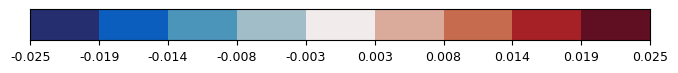




D3_days_Aridity

For ['GWL11C_timescale_1months', 'GWL15C_timescale_1months', 'GWL20C_timescale_1months', 'GWL25C_timescale_1months'], use:

Bin divisions: [16.000, 18.400, 20.800, 23.200, 25.600, 28.000, 30.400, 32.800, 35.200, 37.600, 40.000]
Bin centers: [17.200, 19.600, 22.000, 24.400, 26.800, 29.200, 31.600, 34.000, 36.400, 38.800]
Colors: ["#FDF1D3", "#F1D38A", "#E3B34B", "#D2952C", "#BD761A", "#A9590A", "#933B01", "#7A1C00", "#5A0504", "#2E0808"]


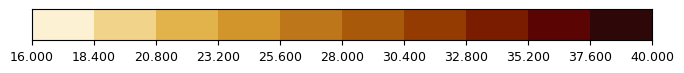


For ['GWL11C_timescale_3months', 'GWL15C_timescale_3months', 'GWL20C_timescale_3months', 'GWL25C_timescale_3months'], use:

Bin divisions: [16.000, 19.900, 23.800, 27.700, 31.600, 35.500, 39.400, 43.300, 47.200, 51.100, 55.000]
Bin centers: [17.950, 21.850, 25.750, 29.650, 33.550, 37.450, 41.350, 45.250, 49.150, 53.050]
Colors: ["#FDF1D3", "#F1D38A", "#E3B34B", "#D2952C", "#BD761A", "#A9590A", "#933B01", "#7A1C00", "#5A0504", "#2E0808"]


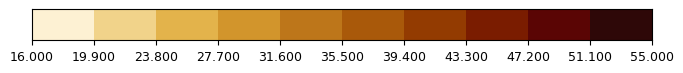


For ['GWL11C_timescale_6months', 'GWL15C_timescale_6months', 'GWL20C_timescale_6months', 'GWL25C_timescale_6months'], use:

Bin divisions: [16.000, 20.900, 25.800, 30.700, 35.600, 40.500, 45.400, 50.300, 55.200, 60.100, 65.000]
Bin centers: [18.450, 23.350, 28.250, 33.150, 38.050, 42.950, 47.850, 52.750, 57.650, 62.550]
Colors: ["#FDF1D3", "#F1D38A", "#E3B34B", "#D2952C", "#BD761A", "#A9590A", "#933B01", "#7A1C00", "#5A0504", "#2E0808"]


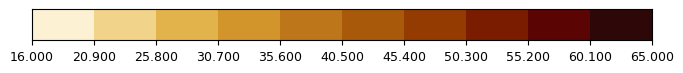


For ['GWL11C_timescale_12months', 'GWL15C_timescale_12months', 'GWL20C_timescale_12months', 'GWL25C_timescale_12months'], use:

Bin divisions: [16.000, 23.400, 30.800, 38.200, 45.600, 53.000, 60.400, 67.800, 75.200, 82.600, 90.000]
Bin centers: [19.700, 27.100, 34.500, 41.900, 49.300, 56.700, 64.100, 71.500, 78.900, 86.300]
Colors: ["#FDF1D3", "#F1D38A", "#E3B34B", "#D2952C", "#BD761A", "#A9590A", "#933B01", "#7A1C00", "#5A0504", "#2E0808"]


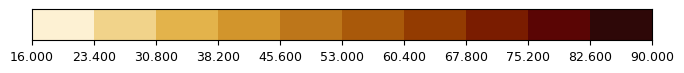


For ['GWL11C_timescale_24months', 'GWL15C_timescale_24months', 'GWL20C_timescale_24months', 'GWL25C_timescale_24months'], use:

Bin divisions: [16.000, 27.900, 39.800, 51.700, 63.600, 75.500, 87.400, 99.300, 111.200, 123.100, 135.000]
Bin centers: [21.950, 33.850, 45.750, 57.650, 69.550, 81.450, 93.350, 105.250, 117.150, 129.050]
Colors: ["#FDF1D3", "#F1D38A", "#E3B34B", "#D2952C", "#BD761A", "#A9590A", "#933B01", "#7A1C00", "#5A0504", "#2E0808"]


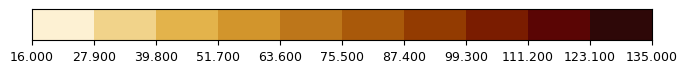




FD
==

For ['GWL11C_minus_REF_absoule_change', 'GWL15C_minus_REF_absoule_change', 'GWL20C_minus_REF_absoule_change', 'GWL25C_minus_REF_absoule_change'], use:

Bin divisions: [-40.000, -31.111, -22.222, -13.333, -4.444, 4.444, 13.333, 22.222, 31.111, 40.000]
Bin centers: [-35.556, -26.667, -17.778, -8.889, 0.000, 8.889, 17.778, 26.667, 35.556]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


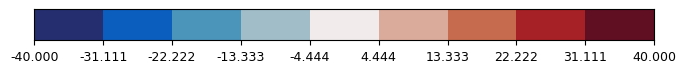


For ['GWL11C_actual_values', 'GWL15C_actual_values', 'GWL20C_actual_values', 'GWL25C_actual_values', 'REF_actual_values'], use:

Bin divisions: [45.000, 66.500, 88.000, 109.500, 131.000, 152.500, 174.000, 195.500, 217.000, 238.500, 260.000]
Bin centers: [55.750, 77.250, 98.750, 120.250, 141.750, 163.250, 184.750, 206.250, 227.750, 249.250]
Colors: ["#E9F5F7", "#C1DEE9", "#9FC4E0", "#90A8D5", "#8F8ABB", "#8A6E9D", "#7B5579", "#674057", "#4F2F39", "#351E1F"]


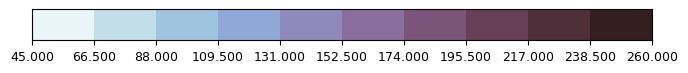




frost_free_season

For ['REF_actual_values'], use:

Bin divisions: [0.000, 36.500, 73.000, 109.500, 146.000, 182.500, 219.000, 255.500, 292.000, 328.500, 365.000]
Bin centers: [18.250, 54.750, 91.250, 127.750, 164.250, 200.750, 237.250, 273.750, 310.250, 346.750]
Colors: ["#EBDFDC", "#E0C0B6", "#D7A291", "#CF866D", "#C5684A", "#BA492F", "#AA2724", "#8E1029", "#6D0E26", "#4B0C19"]


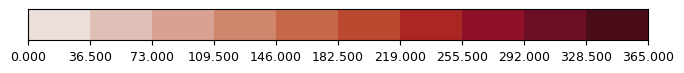


For ['GWL11C_minus_REF_change', 'GWL15C_minus_REF_change', 'GWL20C_minus_REF_change', 'GWL25C_minus_REF_change'], use:

Bin divisions: [-30.000, -23.333, -16.667, -10.000, -3.333, 3.333, 10.000, 16.667, 23.333, 30.000]
Bin centers: [-26.667, -20.000, -13.333, -6.667, 0.000, 6.667, 13.333, 20.000, 26.667]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


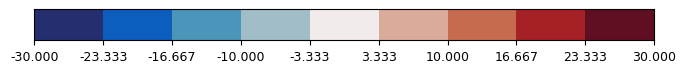




FWI_mean

For ['hist_actual_values', 'GWL11C_actual_values', 'GWL15C_actual_values', 'GWL20C_actual_values', 'GWL25C_actual_values'], use:

Bin divisions: [5.000, 12.000, 19.000, 26.000, 33.000, 40.000, 47.000, 54.000, 61.000, 68.000, 75.000]
Bin centers: [8.500, 15.500, 22.500, 29.500, 36.500, 43.500, 50.500, 57.500, 64.500, 71.500]
Colors: ["#FAEDD7", "#EED3BC", "#E6B8A6", "#E19C99", "#DC7A95", "#D15A98", "#B74199", "#923593", "#6A2F88", "#3E2976"]


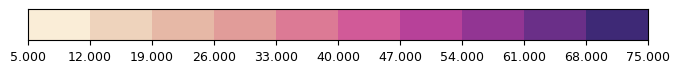




FWI_X95p

For ['GWL11C_actual_values', 'GWL15C_actual_values', 'GWL20C_actual_values', 'GWL25C_actual_values'], use:

Bin divisions: [18.000, 24.500, 31.000, 37.500, 44.000, 50.500, 57.000, 63.500, 70.000, 76.500, 83.000]
Bin centers: [21.250, 27.750, 34.250, 40.750, 47.250, 53.750, 60.250, 66.750, 73.250, 79.750]
Colors: ["#FAEDD7", "#EED3BC", "#E6B8A6", "#E19C99", "#DC7A95", "#D15A98", "#B74199", "#923593", "#6A2F88", "#3E2976"]


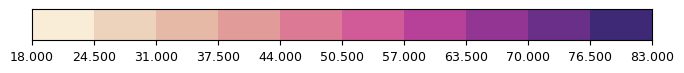




FWSL
====

For ['hist_actual_values', 'GWL11C_actual_values', 'GWL15C_actual_values', 'GWL20C_actual_values', 'GWL25C_actual_values'], use:

Bin divisions: [30.000, 47.000, 64.000, 81.000, 98.000, 115.000, 132.000, 149.000, 166.000, 183.000, 200.000]
Bin centers: [38.500, 55.500, 72.500, 89.500, 106.500, 123.500, 140.500, 157.500, 174.500, 191.500]
Colors: ["#FAEDD7", "#EED3BC", "#E6B8A6", "#E19C99", "#DC7A95", "#D15A98", "#B74199", "#923593", "#6A2F88", "#3E2976"]


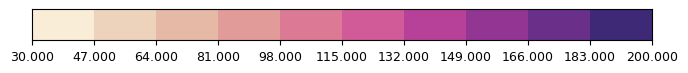




GRAUPEL

For ['sum_mean_CTL_MAMJJAS', 'sum_mean_PGW_MAMJJAS'], use:

Bin divisions: [0.000, 0.030, 0.060, 0.090, 0.120, 0.150, 0.180, 0.210, 0.240, 0.270, 0.300]
Bin centers: [0.015, 0.045, 0.075, 0.105, 0.135, 0.165, 0.195, 0.225, 0.255, 0.285]
Colors: ["#E5F4BE", "#AEE2A9", "#78CEA3", "#5AB6A4", "#4D9BA1", "#44829B", "#3E6896", "#404C8B", "#3E3666", "#30233D"]


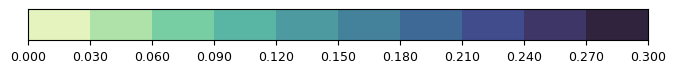


For ['sum_nonzero_mean_CTL_MAMJJAS', 'sum_nonzero_mean_CTL_MJJA', 'sum_nonzero_mean_PGW_MAMJJAS', 'sum_nonzero_mean_PGW_MJJA'], use:

Bin divisions: [0.000, 0.120, 0.240, 0.360, 0.480, 0.600, 0.720, 0.840, 0.960, 1.080, 1.200]
Bin centers: [0.060, 0.180, 0.300, 0.420, 0.540, 0.660, 0.780, 0.900, 1.020, 1.140]
Colors: ["#E5F4BE", "#AEE2A9", "#78CEA3", "#5AB6A4", "#4D9BA1", "#44829B", "#3E6896", "#404C8B", "#3E3666", "#30233D"]


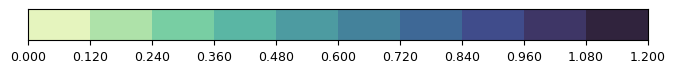


For ['sum_nonzero_diff_PGW_minus_CTL_MAMJJAS', 'sum_nonzero_diff_PGW_minus_CTL_MJJA'], use:

Bin divisions: [-200.000, -155.556, -111.111, -66.667, -22.222, 22.222, 66.667, 111.111, 155.556, 200.000]
Bin centers: [-177.778, -133.333, -88.889, -44.444, 0.000, 44.444, 88.889, 133.333, 177.778]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


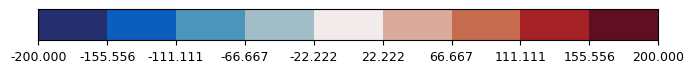


For ['sum_diff_PGW_minus_CTL_MAMJJAS'], use:

Bin divisions: [-70.000, -54.444, -38.889, -23.333, -7.778, 7.778, 23.333, 38.889, 54.444, 70.000]
Bin centers: [-62.222, -46.667, -31.111, -15.556, -0.000, 15.556, 31.111, 46.667, 62.222]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


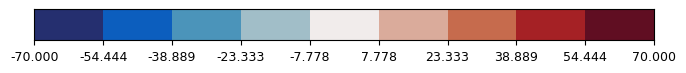




growing_degree_days

For ['REF_actual_values'], use:

Bin divisions: [0.000, 600.000, 1200.000, 1800.000, 2400.000, 3000.000, 3600.000, 4200.000, 4800.000, 5400.000, 6000.000]
Bin centers: [300.000, 900.000, 1500.000, 2100.000, 2700.000, 3300.000, 3900.000, 4500.000, 5100.000, 5700.000]
Colors: ["#EBDFDC", "#E0C0B6", "#D7A291", "#CF866D", "#C5684A", "#BA492F", "#AA2724", "#8E1029", "#6D0E26", "#4B0C19"]


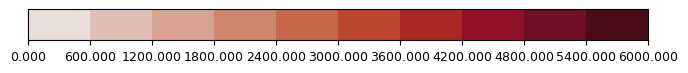


For ['GWL11C_minus_REF_change', 'GWL15C_minus_REF_change', 'GWL20C_minus_REF_change', 'GWL25C_minus_REF_change'], use:

Bin divisions: [-1000.000, -777.778, -555.556, -333.333, -111.111, 111.111, 333.333, 555.556, 777.778, 1000.000]
Bin centers: [-888.889, -666.667, -444.444, -222.222, 0.000, 222.222, 444.444, 666.667, 888.889]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


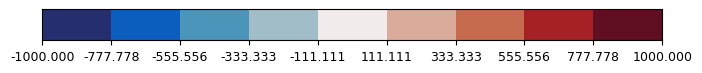




GSL
===

For ['GWL11C_minus_REF_absoule_change', 'GWL15C_minus_REF_absoule_change', 'GWL20C_minus_REF_absoule_change', 'GWL25C_minus_REF_absoule_change'], use:

Bin divisions: [0.000, 4.000, 8.000, 12.000, 16.000, 20.000, 24.000, 28.000, 32.000, 36.000, 40.000]
Bin centers: [2.000, 6.000, 10.000, 14.000, 18.000, 22.000, 26.000, 30.000, 34.000, 38.000]
Colors: ["#E5F5EB", "#B8E5D0", "#79D5BD", "#32C3B1", "#00ABA7", "#13949C", "#267B8D", "#31637A", "#334D65", "#2E394F"]


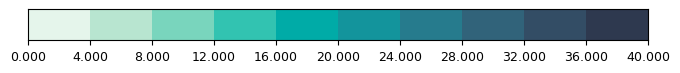


For ['GWL11C_actual_values', 'GWL15C_actual_values', 'GWL20C_actual_values', 'GWL25C_actual_values', 'REF_actual_values'], use:

Bin divisions: [75.000, 100.000, 125.000, 150.000, 175.000, 200.000, 225.000, 250.000, 275.000, 300.000, 325.000]
Bin centers: [87.500, 112.500, 137.500, 162.500, 187.500, 212.500, 237.500, 262.500, 287.500, 312.500]
Colors: ["#E9F5F7", "#C1DEE9", "#9FC4E0", "#90A8D5", "#8F8ABB", "#8A6E9D", "#7B5579", "#674057", "#4F2F39", "#351E1F"]


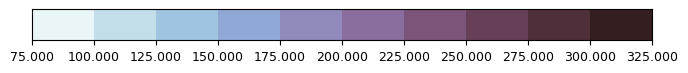




HaildaysG

For ['total_CTL_MAMJJAS', 'total_PGW_MAMJJAS'], use:

Bin divisions: [0.000, 0.200, 0.400, 0.600, 0.800, 1.000, 1.200, 1.400, 1.600, 1.800, 2.000]
Bin centers: [0.100, 0.300, 0.500, 0.700, 0.900, 1.100, 1.300, 1.500, 1.700, 1.900]
Colors: ["#E5F4BE", "#AEE2A9", "#78CEA3", "#5AB6A4", "#4D9BA1", "#44829B", "#3E6896", "#404C8B", "#3E3666", "#30233D"]


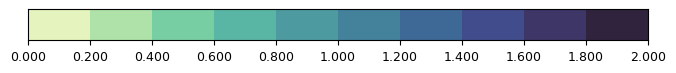


For ['diff_PGW_minus_CTL_MAMJJAS'], use:

Bin divisions: [-2.000, -1.556, -1.111, -0.667, -0.222, 0.222, 0.667, 1.111, 1.556, 2.000]
Bin centers: [-1.778, -1.333, -0.889, -0.444, 0.000, 0.444, 0.889, 1.333, 1.778]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


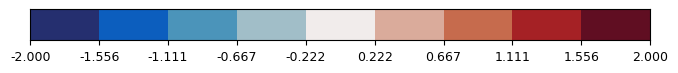




HaildaysW

For ['total_CTL_MAMJJAS', 'total_PGW_MAMJJAS'], use:

Bin divisions: [0.000, 0.700, 1.400, 2.100, 2.800, 3.500, 4.200, 4.900, 5.600, 6.300, 7.000]
Bin centers: [0.350, 1.050, 1.750, 2.450, 3.150, 3.850, 4.550, 5.250, 5.950, 6.650]
Colors: ["#E5F4BE", "#AEE2A9", "#7ACEA3", "#5AB6A4", "#4D9BA1", "#44829B", "#3E6896", "#404C8B", "#3E3666", "#30233D"]


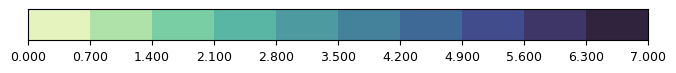


For ['diff_PGW_minus_CTL_MAMJJAS'], use:

Bin divisions: [-7.000, -5.444, -3.889, -2.333, -0.778, 0.778, 2.333, 3.889, 5.444, 7.000]
Bin centers: [-6.222, -4.667, -3.111, -1.556, 0.000, 1.556, 3.111, 4.667, 6.222]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


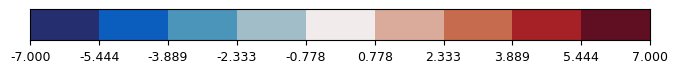




HKE_annual

For ['PGW', 'REF'], use:

Bin divisions: [0.000, 0.180, 0.360, 0.540, 0.720, 0.900, 1.080, 1.260, 1.440, 1.620, 1.800]
Bin centers: [0.090, 0.270, 0.450, 0.630, 0.810, 0.990, 1.170, 1.350, 1.530, 1.710]
Colors: ["#FCDCA0", "#F8B880", "#F29567", "#E97356", "#D95153", "#C2385A", "#A42662", "#821C63", "#61185A", "#3E1348"]


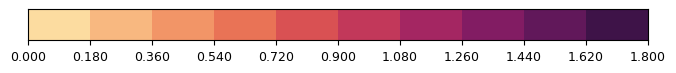


For ['PGW_minus_REF'], use:

Bin divisions: [-0.900, -0.700, -0.500, -0.300, -0.100, 0.100, 0.300, 0.500, 0.700, 0.900]
Bin centers: [-0.800, -0.600, -0.400, -0.200, 0.000, 0.200, 0.400, 0.600, 0.800]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


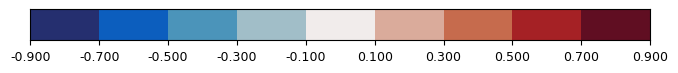




mean_annual_temp

For ['REF_actual_values'], use:

Bin divisions: [20.000, 24.000, 28.000, 32.000, 36.000, 40.000, 44.000, 48.000, 52.000, 56.000, 60.000]
Bin centers: [22.000, 26.000, 30.000, 34.000, 38.000, 42.000, 46.000, 50.000, 54.000, 58.000]
Colors: ["#F4F3F2", "#DDDAD2", "#C8C2AC", "#B7A988", "#AA8E6B", "#9E745A", "#90584A", "#813D38", "#6E2524", "#580B0F"]


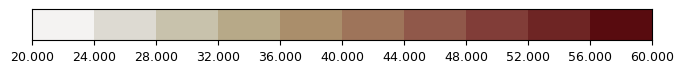


For ['GWL11C_minus_REF_change', 'GWL15C_minus_REF_change', 'GWL20C_minus_REF_change', 'GWL25C_minus_REF_change'], use:

Bin divisions: [-6.000, -4.667, -3.333, -2.000, -0.667, 0.667, 2.000, 3.333, 4.667, 6.000]
Bin centers: [-5.333, -4.000, -2.667, -1.333, -0.000, 1.333, 2.667, 4.000, 5.333]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


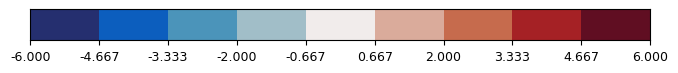




MLCAPE3pm

For ['mean_CTL_MAMJJAS', 'mean_PGW_MAMJJAS'], use:

Bin divisions: [0.000, 40.000, 80.000, 120.000, 160.000, 200.000, 240.000, 280.000, 320.000, 360.000, 400.000]
Bin centers: [20.000, 60.000, 100.000, 140.000, 180.000, 220.000, 260.000, 300.000, 340.000, 380.000]
Colors: ["#FCDCA0", "#F8B880", "#F29567", "#E97356", "#D95153", "#C2385A", "#A42662", "#821C63", "#61185A", "#3E1348"]


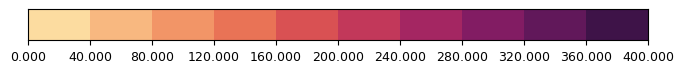


For ['diff_PGW_minus_CTL_MAMJJAS'], use:

Bin divisions: [-50.000, -38.889, -27.778, -16.667, -5.556, 5.556, 16.667, 27.778, 38.889, 50.000]
Bin centers: [-44.444, -33.333, -22.222, -11.111, 0.000, 11.111, 22.222, 33.333, 44.444]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


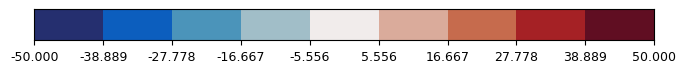




MLCINH3pm

For ['mean_CTL_MAMJJAS', 'mean_PGW_MAMJJAS'], use:

Bin divisions: [-25.000, -22.222, -19.444, -16.667, -13.889, -11.111, -8.333, -5.556, -2.778, 0.000]
Bin centers: [-23.611, -20.833, -18.056, -15.278, -12.500, -9.722, -6.944, -4.167, -1.389]
Colors: ["#41134A", "#66185C", "#8D1E63", "#B02C5F", "#CF4456", "#E46653", "#F08B61", "#F7B37C", "#FCDA9D"]


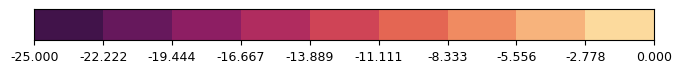


For ['diff_PGW_minus_CTL_MAMJJAS'], use:

Bin divisions: [-35.000, -27.222, -19.444, -11.667, -3.889, 3.889, 11.667, 19.444, 27.222, 35.000]
Bin centers: [-31.111, -23.333, -15.556, -7.778, -0.000, 7.778, 15.556, 23.333, 31.111]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


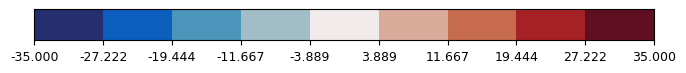




Mxdbz
=====

For ['climo_Adiff_PGW_minus_CTL_MAMJJAS'], use:

Bin divisions: [-1.000, -0.778, -0.556, -0.333, -0.111, 0.111, 0.333, 0.556, 0.778, 1.000]
Bin centers: [-0.889, -0.667, -0.444, -0.222, 0.000, 0.222, 0.444, 0.667, 0.889]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


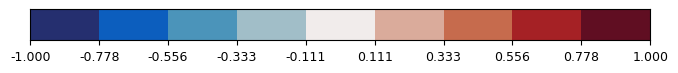


For ['climo_Pdiff_PGW_minus_CTL_MAMJJAS'], use:

Bin divisions: [-5.000, -3.889, -2.778, -1.667, -0.556, 0.556, 1.667, 2.778, 3.889, 5.000]
Bin centers: [-4.444, -3.333, -2.222, -1.111, 0.000, 1.111, 2.222, 3.333, 4.444]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


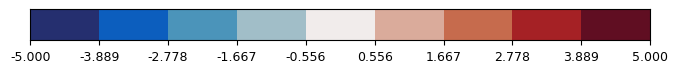


For ['p95_Adiff_PGW_minus_CTL_MAMJJAS'], use:

Bin divisions: [-4.000, -3.111, -2.222, -1.333, -0.444, 0.444, 1.333, 2.222, 3.111, 4.000]
Bin centers: [-3.556, -2.667, -1.778, -0.889, 0.000, 0.889, 1.778, 2.667, 3.556]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


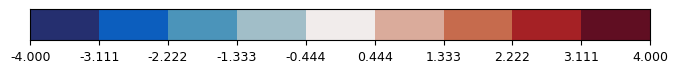


For ['p95_Pdiff_PGW_minus_CTL_MAMJJAS'], use:

Bin divisions: [-8.000, -6.222, -4.444, -2.667, -0.889, 0.889, 2.667, 4.444, 6.222, 8.000]
Bin centers: [-7.111, -5.333, -3.556, -1.778, 0.000, 1.778, 3.556, 5.333, 7.111]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


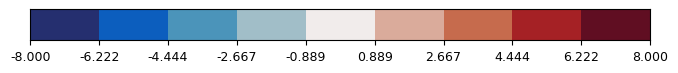


For ['mean_CTL_MAMJJAS', 'mean_PGW_MAMJJAS'], use:

Bin divisions: [23.000, 23.500, 24.000, 24.500, 25.000, 25.500, 26.000, 26.500, 27.000, 27.500, 28.000]
Bin centers: [23.250, 23.750, 24.250, 24.750, 25.250, 25.750, 26.250, 26.750, 27.250, 27.750]
Colors: ["#FCDCA0", "#F8B880", "#F29567", "#E97356", "#D95153", "#C2385A", "#A42662", "#821C63", "#61185A", "#3E1348"]


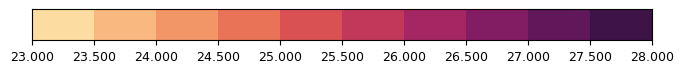


For ['p95_max_CTL_MAMJJAS', 'p95_max_PGW_MAMJJAS'], use:

Bin divisions: [40.000, 41.000, 42.000, 43.000, 44.000, 45.000, 46.000, 47.000, 48.000, 49.000, 50.000]
Bin centers: [40.500, 41.500, 42.500, 43.500, 44.500, 45.500, 46.500, 47.500, 48.500, 49.500]
Colors: ["#FCDCA0", "#F8B880", "#F29567", "#E97356", "#D95153", "#C2385A", "#A42662", "#821C63", "#61185A", "#3E1348"]


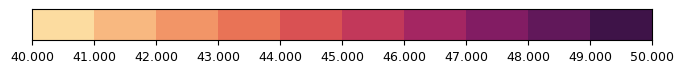




Mxdbzh

For ['climo_Adiff_PGW_minus_CTL_MAMJJAS'], use:

Bin divisions: [-220.000, -171.111, -122.222, -73.333, -24.444, 24.444, 73.333, 122.222, 171.111, 220.000]
Bin centers: [-195.556, -146.667, -97.778, -48.889, -0.000, 48.889, 97.778, 146.667, 195.556]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


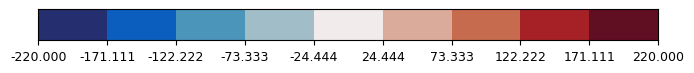


For ['climo_Pdiff_PGW_minus_CTL_MAMJJAS'], use:

Bin divisions: [-30.000, -23.333, -16.667, -10.000, -3.333, 3.333, 10.000, 16.667, 23.333, 30.000]
Bin centers: [-26.667, -20.000, -13.333, -6.667, 0.000, 6.667, 13.333, 20.000, 26.667]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


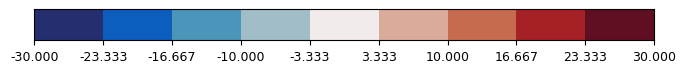


For ['p95_Adiff_PGW_minus_CTL_MAMJJAS'], use:

Bin divisions: [-1000.000, -777.778, -555.556, -333.333, -111.111, 111.111, 333.333, 555.556, 777.778, 1000.000]
Bin centers: [-888.889, -666.667, -444.444, -222.222, 0.000, 222.222, 444.444, 666.667, 888.889]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


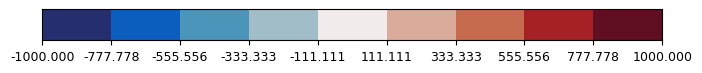


For ['p95_Pdiff_PGW_minus_CTL_MAMJJAS'], use:

Bin divisions: [-30.000, -23.333, -16.667, -10.000, -3.333, 3.333, 10.000, 16.667, 23.333, 30.000]
Bin centers: [-26.667, -20.000, -13.333, -6.667, 0.000, 6.667, 13.333, 20.000, 26.667]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


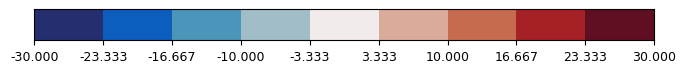


For ['mean_CTL_MAMJJAS', 'mean_PGW_MAMJJAS'], use:

Bin divisions: [350.000, 585.000, 820.000, 1055.000, 1290.000, 1525.000, 1760.000, 1995.000, 2230.000, 2465.000, 2700.000]
Bin centers: [467.500, 702.500, 937.500, 1172.500, 1407.500, 1642.500, 1877.500, 2112.500, 2347.500, 2582.500]
Colors: ["#FCDCA0", "#F8B880", "#F29567", "#E97356", "#D95153", "#C2385A", "#A42662", "#821C63", "#61185A", "#3E1348"]


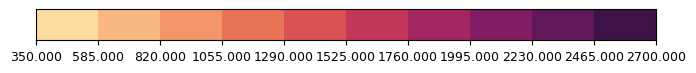


For ['p95_max_CTL_MAMJJAS', 'p95_max_PGW_MAMJJAS'], use:

Bin divisions: [2600.000, 3040.000, 3480.000, 3920.000, 4360.000, 4800.000, 5240.000, 5680.000, 6120.000, 6560.000, 7000.000]
Bin centers: [2820.000, 3260.000, 3700.000, 4140.000, 4580.000, 5020.000, 5460.000, 5900.000, 6340.000, 6780.000]
Colors: ["#FCDCA0", "#F8B880", "#F29567", "#E97356", "#D95153", "#C2385A", "#A42662", "#821C63", "#61185A", "#3E1348"]


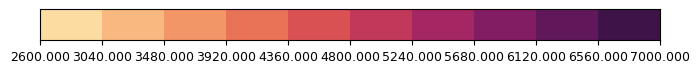




Mxht
====

For ['00_climo_Adiff_PGW_minus_CTL_MAMJJAS'], use:

Bin divisions: [-325.000, -252.778, -180.556, -108.333, -36.111, 36.111, 108.333, 180.556, 252.778, 325.000]
Bin centers: [-288.889, -216.667, -144.444, -72.222, 0.000, 72.222, 144.444, 216.667, 288.889]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


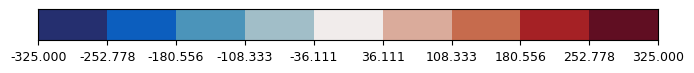


For ['00_climo_Pdiff_PGW_minus_CTL_MAMJJAS'], use:

Bin divisions: [-12.000, -9.333, -6.667, -4.000, -1.333, 1.333, 4.000, 6.667, 9.333, 12.000]
Bin centers: [-10.667, -8.000, -5.333, -2.667, -0.000, 2.667, 5.333, 8.000, 10.667]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


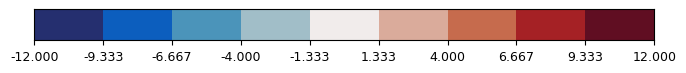


For ['00_p95_Adiff_PGW_minus_CTL_MAMJJAS'], use:

Bin divisions: [-1000.000, -777.778, -555.556, -333.333, -111.111, 111.111, 333.333, 555.556, 777.778, 1000.000]
Bin centers: [-888.889, -666.667, -444.444, -222.222, 0.000, 222.222, 444.444, 666.667, 888.889]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


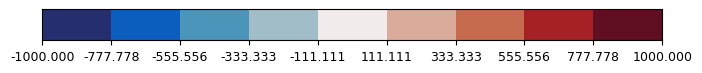


For ['00_p95_Pdiff_PGW_minus_CTL_MAMJJAS'], use:

Bin divisions: [-13.000, -10.111, -7.222, -4.333, -1.444, 1.444, 4.333, 7.222, 10.111, 13.000]
Bin centers: [-11.556, -8.667, -5.778, -2.889, 0.000, 2.889, 5.778, 8.667, 11.556]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


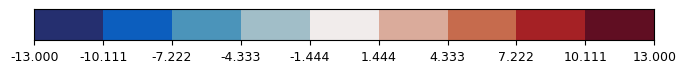


For ['00_mean_CTL_MAMJJAS', '00_mean_PGW_MAMJJAS'], use:

Bin divisions: [2000.000, 2350.000, 2700.000, 3050.000, 3400.000, 3750.000, 4100.000, 4450.000, 4800.000, 5150.000, 5500.000]
Bin centers: [2175.000, 2525.000, 2875.000, 3225.000, 3575.000, 3925.000, 4275.000, 4625.000, 4975.000, 5325.000]
Colors: ["#FCDCA0", "#F8B880", "#F29567", "#E97356", "#D95153", "#C2385A", "#A42662", "#821C63", "#61185A", "#3E1348"]


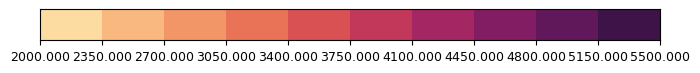


For ['p95_00_max_CTL_MAMJJAS', 'p95_00_max_PGW_MAMJJAS'], use:

Bin divisions: [6500.000, 6950.000, 7400.000, 7850.000, 8300.000, 8750.000, 9200.000, 9650.000, 10100.000, 10550.000, 11000.000]
Bin centers: [6725.000, 7175.000, 7625.000, 8075.000, 8525.000, 8975.000, 9425.000, 9875.000, 10325.000, 10775.000]
Colors: ["#FCDCA0", "#F8B880", "#F29567", "#E97356", "#D95153", "#C2385A", "#A42662", "#821C63", "#61185A", "#3E1348"]


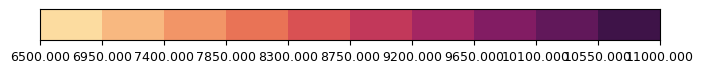


For ['30_climo_Adiff_PGW_minus_CTL_MAMJJAS', '35_climo_Adiff_PGW_minus_CTL_MAMJJAS', '40_climo_Adiff_PGW_minus_CTL_MAMJJAS'], use:

Bin divisions: [-450.000, -350.000, -250.000, -150.000, -50.000, 50.000, 150.000, 250.000, 350.000, 450.000]
Bin centers: [-400.000, -300.000, -200.000, -100.000, 0.000, 100.000, 200.000, 300.000, 400.000]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


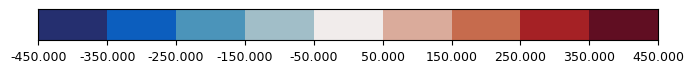


For ['30_climo_Pdiff_PGW_minus_CTL_MAMJJAS', '35_climo_Pdiff_PGW_minus_CTL_MAMJJAS', '40_climo_Pdiff_PGW_minus_CTL_MAMJJAS'], use:

Bin divisions: [-40.000, -31.111, -22.222, -13.333, -4.444, 4.444, 13.333, 22.222, 31.111, 40.000]
Bin centers: [-35.556, -26.667, -17.778, -8.889, 0.000, 8.889, 17.778, 26.667, 35.556]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


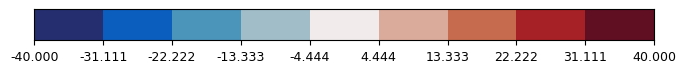


For ['30_p95_Adiff_PGW_minus_CTL_MAMJJAS', '35_p95_Adiff_PGW_minus_CTL_MAMJJAS', '40_p95_Adiff_PGW_minus_CTL_MAMJJAS'], use:

Bin divisions: [-2500.000, -1944.444, -1388.889, -833.333, -277.778, 277.778, 833.333, 1388.889, 1944.444, 2500.000]
Bin centers: [-2222.222, -1666.667, -1111.111, -555.556, 0.000, 555.556, 1111.111, 1666.667, 2222.222]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


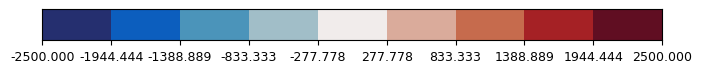


For ['30_p95_Pdiff_PGW_minus_CTL_MAMJJAS', '35_p95_Pdiff_PGW_minus_CTL_MAMJJAS', '40_p95_Pdiff_PGW_minus_CTL_MAMJJAS'], use:

Bin divisions: [-60.000, -46.667, -33.333, -20.000, -6.667, 6.667, 20.000, 33.333, 46.667, 60.000]
Bin centers: [-53.333, -40.000, -26.667, -13.333, 0.000, 13.333, 26.667, 40.000, 53.333]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


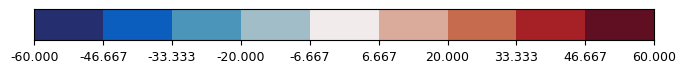


For ['30_mean_CTL_MAMJJAS', '35_mean_CTL_MAMJJAS', '40_mean_CTL_MAMJJAS', '30_mean_PGW_MAMJJAS', '35_mean_PGW_MAMJJAS', '40_mean_PGW_MAMJJAS'], use:

Bin divisions: [800.000, 1070.000, 1340.000, 1610.000, 1880.000, 2150.000, 2420.000, 2690.000, 2960.000, 3230.000, 3500.000]
Bin centers: [935.000, 1205.000, 1475.000, 1745.000, 2015.000, 2285.000, 2555.000, 2825.000, 3095.000, 3365.000]
Colors: ["#FCDCA0", "#F8B880", "#F29567", "#E97356", "#D95153", "#C2385A", "#A42662", "#821C63", "#61185A", "#3E1348"]


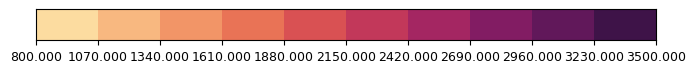


For ['p95_30_max_CTL_MAMJJAS', 'p95_35_max_CTL_MAMJJAS', 'p95_40_max_CTL_MAMJJAS', 'p95_30_max_PGW_MAMJJAS', 'p95_35_max_PGW_MAMJJAS', 'p95_40_max_PGW_MAMJJAS'], use:

Bin divisions: [2000.000, 2800.000, 3600.000, 4400.000, 5200.000, 6000.000, 6800.000, 7600.000, 8400.000, 9200.000, 10000.000]
Bin centers: [2400.000, 3200.000, 4000.000, 4800.000, 5600.000, 6400.000, 7200.000, 8000.000, 8800.000, 9600.000]
Colors: ["#FCDCA0", "#F8B880", "#F29567", "#E97356", "#D95153", "#C2385A", "#A42662", "#821C63", "#61185A", "#3E1348"]


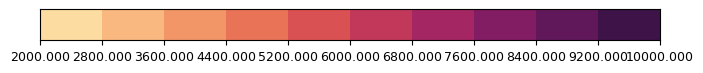




pct_change_Aridity

For ['GWL11C_D1_timescale_1months', 'GWL15C_D1_timescale_1months', 'GWL20C_D1_timescale_1months', 'GWL25C_D1_timescale_1months'], use:

Bin divisions: [-60.000, -46.667, -33.333, -20.000, -6.667, 6.667, 20.000, 33.333, 46.667, 60.000]
Bin centers: [-53.333, -40.000, -26.667, -13.333, 0.000, 13.333, 26.667, 40.000, 53.333]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


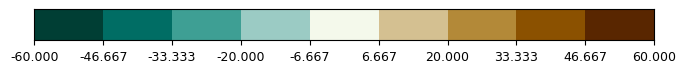


For ['GWL11C_D1_timescale_3months', 'GWL15C_D1_timescale_3months', 'GWL20C_D1_timescale_3months', 'GWL25C_D1_timescale_3months'], use:

Bin divisions: [-90.000, -70.000, -50.000, -30.000, -10.000, 10.000, 30.000, 50.000, 70.000, 90.000]
Bin centers: [-80.000, -60.000, -40.000, -20.000, 0.000, 20.000, 40.000, 60.000, 80.000]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


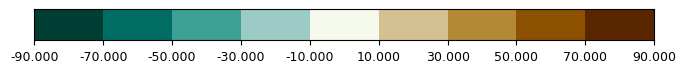


For ['GWL11C_D1_timescale_6months', 'GWL15C_D1_timescale_6months', 'GWL20C_D1_timescale_6months', 'GWL25C_D1_timescale_6months'], use:

Bin divisions: [-120.000, -93.333, -66.667, -40.000, -13.333, 13.333, 40.000, 66.667, 93.333, 120.000]
Bin centers: [-106.667, -80.000, -53.333, -26.667, 0.000, 26.667, 53.333, 80.000, 106.667]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


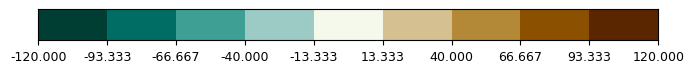


For ['GWL11C_D1_timescale_12months', 'GWL15C_D1_timescale_12months', 'GWL20C_D1_timescale_12months', 'GWL25C_D1_timescale_12months'], use:

Bin divisions: [-180.000, -140.000, -100.000, -60.000, -20.000, 20.000, 60.000, 100.000, 140.000, 180.000]
Bin centers: [-160.000, -120.000, -80.000, -40.000, 0.000, 40.000, 80.000, 120.000, 160.000]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


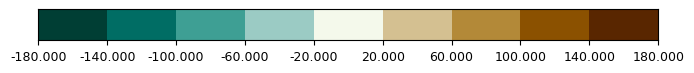


For ['GWL11C_D1_timescale_24months', 'GWL15C_D1_timescale_24months', 'GWL20C_D1_timescale_24months', 'GWL25C_D1_timescale_24months'], use:

Bin divisions: [-240.000, -186.667, -133.333, -80.000, -26.667, 26.667, 80.000, 133.333, 186.667, 240.000]
Bin centers: [-213.333, -160.000, -106.667, -53.333, 0.000, 53.333, 106.667, 160.000, 213.333]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


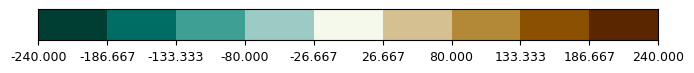


For ['GWL11C_D2_timescale_1months', 'GWL15C_D2_timescale_1months', 'GWL20C_D2_timescale_1months', 'GWL25C_D2_timescale_1months'], use:

Bin divisions: [-80.000, -62.222, -44.444, -26.667, -8.889, 8.889, 26.667, 44.444, 62.222, 80.000]
Bin centers: [-71.111, -53.333, -35.556, -17.778, 0.000, 17.778, 35.556, 53.333, 71.111]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


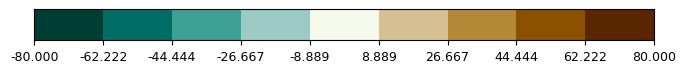


For ['GWL11C_D2_timescale_3months', 'GWL15C_D2_timescale_3months', 'GWL20C_D2_timescale_3months', 'GWL25C_D2_timescale_3months'], use:

Bin divisions: [-140.000, -108.889, -77.778, -46.667, -15.556, 15.556, 46.667, 77.778, 108.889, 140.000]
Bin centers: [-124.444, -93.333, -62.222, -31.111, -0.000, 31.111, 62.222, 93.333, 124.444]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


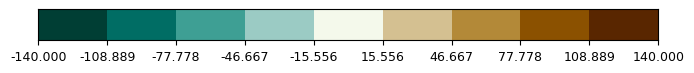


For ['GWL11C_D2_timescale_6months', 'GWL15C_D2_timescale_6months', 'GWL20C_D2_timescale_6months', 'GWL25C_D2_timescale_6months'], use:

Bin divisions: [-190.000, -147.778, -105.556, -63.333, -21.111, 21.111, 63.333, 105.556, 147.778, 190.000]
Bin centers: [-168.889, -126.667, -84.444, -42.222, 0.000, 42.222, 84.444, 126.667, 168.889]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


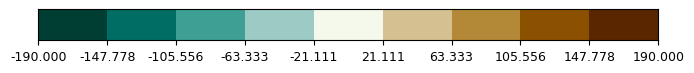


For ['GWL11C_D2_timescale_12months', 'GWL15C_D2_timescale_12months', 'GWL20C_D2_timescale_12months', 'GWL25C_D2_timescale_12months'], use:

Bin divisions: [-260.000, -202.222, -144.444, -86.667, -28.889, 28.889, 86.667, 144.444, 202.222, 260.000]
Bin centers: [-231.111, -173.333, -115.556, -57.778, 0.000, 57.778, 115.556, 173.333, 231.111]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


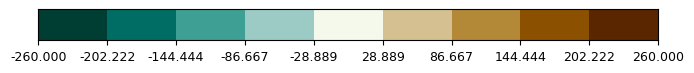


For ['GWL11C_D2_timescale_24months', 'GWL15C_D2_timescale_24months', 'GWL20C_D2_timescale_24months', 'GWL25C_D2_timescale_24months'], use:

Bin divisions: [-400.000, -311.111, -222.222, -133.333, -44.444, 44.444, 133.333, 222.222, 311.111, 400.000]
Bin centers: [-355.556, -266.667, -177.778, -88.889, 0.000, 88.889, 177.778, 266.667, 355.556]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


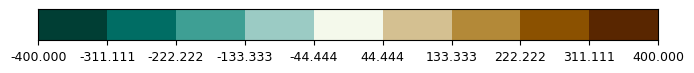


For ['GWL11C_D3_timescale_1months', 'GWL15C_D3_timescale_1months', 'GWL20C_D3_timescale_1months', 'GWL25C_D3_timescale_1months'], use:

Bin divisions: [-110.000, -85.556, -61.111, -36.667, -12.222, 12.222, 36.667, 61.111, 85.556, 110.000]
Bin centers: [-97.778, -73.333, -48.889, -24.444, -0.000, 24.444, 48.889, 73.333, 97.778]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


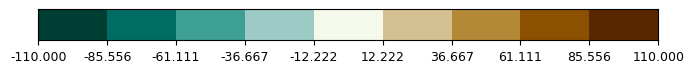


For ['GWL11C_D3_timescale_3months', 'GWL15C_D3_timescale_3months', 'GWL20C_D3_timescale_3months', 'GWL25C_D3_timescale_3months'], use:

Bin divisions: [-190.000, -147.778, -105.556, -63.333, -21.111, 21.111, 63.333, 105.556, 147.778, 190.000]
Bin centers: [-168.889, -126.667, -84.444, -42.222, 0.000, 42.222, 84.444, 126.667, 168.889]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


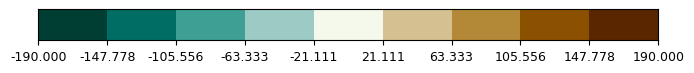


For ['GWL11C_D3_timescale_6months', 'GWL15C_D3_timescale_6months', 'GWL20C_D3_timescale_6months', 'GWL25C_D3_timescale_6months'], use:

Bin divisions: [-260.000, -202.222, -144.444, -86.667, -28.889, 28.889, 86.667, 144.444, 202.222, 260.000]
Bin centers: [-231.111, -173.333, -115.556, -57.778, 0.000, 57.778, 115.556, 173.333, 231.111]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


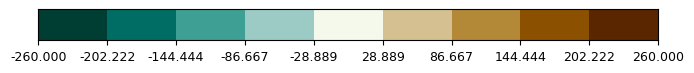


For ['GWL11C_D3_timescale_12months', 'GWL15C_D3_timescale_12months', 'GWL20C_D3_timescale_12months', 'GWL25C_D3_timescale_12months'], use:

Bin divisions: [-400.000, -311.111, -222.222, -133.333, -44.444, 44.444, 133.333, 222.222, 311.111, 400.000]
Bin centers: [-355.556, -266.667, -177.778, -88.889, 0.000, 88.889, 177.778, 266.667, 355.556]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


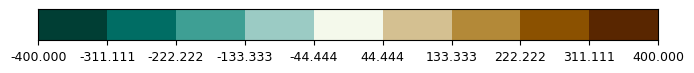


For ['GWL11C_D3_timescale_24months', 'GWL15C_D3_timescale_24months', 'GWL20C_D3_timescale_24months', 'GWL25C_D3_timescale_24months'], use:

Bin divisions: [-640.000, -497.778, -355.556, -213.333, -71.111, 71.111, 213.333, 355.556, 497.778, 640.000]
Bin centers: [-568.889, -426.667, -284.444, -142.222, 0.000, 142.222, 284.444, 426.667, 568.889]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


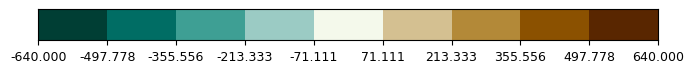


For ['GWL11C_D4_timescale_1months', 'GWL15C_D4_timescale_1months', 'GWL20C_D4_timescale_1months', 'GWL25C_D4_timescale_1months'], use:

Bin divisions: [-200.000, -155.556, -111.111, -66.667, -22.222, 22.222, 66.667, 111.111, 155.556, 200.000]
Bin centers: [-177.778, -133.333, -88.889, -44.444, 0.000, 44.444, 88.889, 133.333, 177.778]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


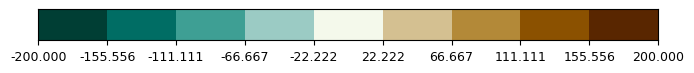


For ['GWL11C_D4_timescale_3months', 'GWL15C_D4_timescale_3months', 'GWL20C_D4_timescale_3months', 'GWL25C_D4_timescale_3months'], use:

Bin divisions: [-300.000, -233.333, -166.667, -100.000, -33.333, 33.333, 100.000, 166.667, 233.333, 300.000]
Bin centers: [-266.667, -200.000, -133.333, -66.667, 0.000, 66.667, 133.333, 200.000, 266.667]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


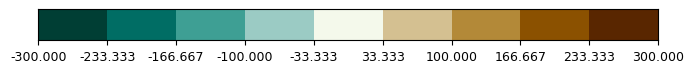


For ['GWL11C_D4_timescale_6months', 'GWL15C_D4_timescale_6months', 'GWL20C_D4_timescale_6months', 'GWL25C_D4_timescale_6months'], use:

Bin divisions: [-400.000, -311.111, -222.222, -133.333, -44.444, 44.444, 133.333, 222.222, 311.111, 400.000]
Bin centers: [-355.556, -266.667, -177.778, -88.889, 0.000, 88.889, 177.778, 266.667, 355.556]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


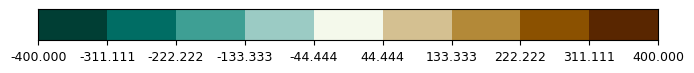


For ['GWL11C_D4_timescale_12months', 'GWL15C_D4_timescale_12months', 'GWL20C_D4_timescale_12months', 'GWL25C_D4_timescale_12months'], use:

Bin divisions: [-640.000, -497.778, -355.556, -213.333, -71.111, 71.111, 213.333, 355.556, 497.778, 640.000]
Bin centers: [-568.889, -426.667, -284.444, -142.222, 0.000, 142.222, 284.444, 426.667, 568.889]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


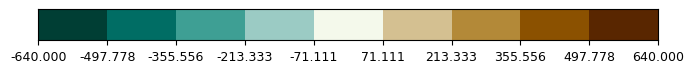


For ['GWL11C_D4_timescale_24months', 'GWL15C_D4_timescale_24months', 'GWL20C_D4_timescale_24months', 'GWL25C_D4_timescale_24months'], use:

Bin divisions: [-1200.000, -933.333, -666.667, -400.000, -133.333, 133.333, 400.000, 666.667, 933.333, 1200.000]
Bin centers: [-1066.667, -800.000, -533.333, -266.667, 0.000, 266.667, 533.333, 800.000, 1066.667]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


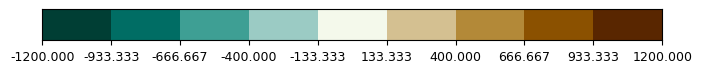




pct_change_RZSM

For ['GWL11C_annual', 'GWL11C_apr', 'GWL11C_aug', 'GWL11C_dec', 'GWL11C_feb', 'GWL11C_jan', 'GWL11C_jul', 'GWL11C_jun', 'GWL11C_mar', 'GWL11C_may', 'GWL11C_nov', 'GWL11C_oct', 'GWL11C_sep', 'GWL15C_annual', 'GWL15C_apr', 'GWL15C_aug', 'GWL15C_dec', 'GWL15C_feb', 'GWL15C_jan', 'GWL15C_jul', 'GWL15C_jun', 'GWL15C_mar', 'GWL15C_may', 'GWL15C_nov', 'GWL15C_oct', 'GWL15C_sep', 'GWL20C_annual', 'GWL20C_apr', 'GWL20C_aug', 'GWL20C_dec', 'GWL20C_feb', 'GWL20C_jan', 'GWL20C_jul', 'GWL20C_jun', 'GWL20C_mar', 'GWL20C_may', 'GWL20C_nov', 'GWL20C_oct', 'GWL20C_sep', 'GWL25C_annual', 'GWL25C_apr', 'GWL25C_aug', 'GWL25C_dec', 'GWL25C_feb', 'GWL25C_jan', 'GWL25C_jul', 'GWL25C_jun', 'GWL25C_mar', 'GWL25C_may', 'GWL25C_nov', 'GWL25C_oct', 'GWL25C_sep'], use:

Bin divisions: [-20.000, -15.556, -11.111, -6.667, -2.222, 2.222, 6.667, 11.111, 15.556, 20.000]
Bin centers: [-17.778, -13.333, -8.889, -4.444, 0.000, 4.444, 8.889, 13.333, 17.778]
Colors: ["#592600", "#8B5100", "#B38938", "#D4

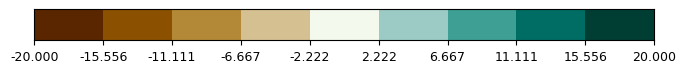




pct_change_SPI

For ['GWL11C_D1_timescale_1months', 'GWL15C_D1_timescale_1months', 'GWL20C_D1_timescale_1months', 'GWL25C_D1_timescale_1months'], use:

Bin divisions: [-30.000, -23.333, -16.667, -10.000, -3.333, 3.333, 10.000, 16.667, 23.333, 30.000]
Bin centers: [-26.667, -20.000, -13.333, -6.667, 0.000, 6.667, 13.333, 20.000, 26.667]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


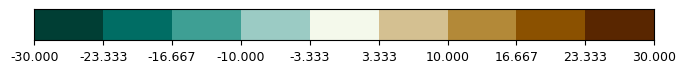


For ['GWL11C_D1_timescale_3months', 'GWL15C_D1_timescale_3months', 'GWL20C_D1_timescale_3months', 'GWL25C_D1_timescale_3months'], use:

Bin divisions: [-60.000, -46.667, -33.333, -20.000, -6.667, 6.667, 20.000, 33.333, 46.667, 60.000]
Bin centers: [-53.333, -40.000, -26.667, -13.333, 0.000, 13.333, 26.667, 40.000, 53.333]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


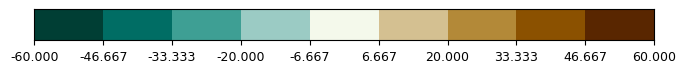


For ['GWL11C_D1_timescale_6months', 'GWL15C_D1_timescale_6months', 'GWL20C_D1_timescale_6months', 'GWL25C_D1_timescale_6months'], use:

Bin divisions: [-70.000, -54.444, -38.889, -23.333, -7.778, 7.778, 23.333, 38.889, 54.444, 70.000]
Bin centers: [-62.222, -46.667, -31.111, -15.556, -0.000, 15.556, 31.111, 46.667, 62.222]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


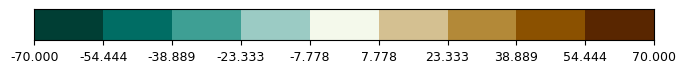


For ['GWL11C_D1_timescale_12months', 'GWL15C_D1_timescale_12months', 'GWL20C_D1_timescale_12months', 'GWL25C_D1_timescale_12months'], use:

Bin divisions: [-100.000, -77.778, -55.556, -33.333, -11.111, 11.111, 33.333, 55.556, 77.778, 100.000]
Bin centers: [-88.889, -66.667, -44.444, -22.222, 0.000, 22.222, 44.444, 66.667, 88.889]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


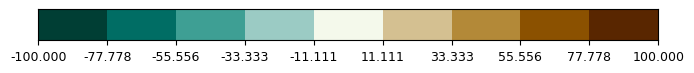


For ['GWL11C_D1_timescale_24months', 'GWL15C_D1_timescale_24months', 'GWL20C_D1_timescale_24months', 'GWL25C_D1_timescale_24months'], use:

Bin divisions: [-140.000, -108.889, -77.778, -46.667, -15.556, 15.556, 46.667, 77.778, 108.889, 140.000]
Bin centers: [-124.444, -93.333, -62.222, -31.111, -0.000, 31.111, 62.222, 93.333, 124.444]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


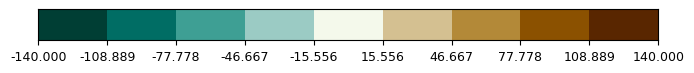


For ['GWL11C_D2_timescale_1months', 'GWL15C_D2_timescale_1months', 'GWL20C_D2_timescale_1months', 'GWL25C_D2_timescale_1months'], use:

Bin divisions: [-60.000, -46.667, -33.333, -20.000, -6.667, 6.667, 20.000, 33.333, 46.667, 60.000]
Bin centers: [-53.333, -40.000, -26.667, -13.333, 0.000, 13.333, 26.667, 40.000, 53.333]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


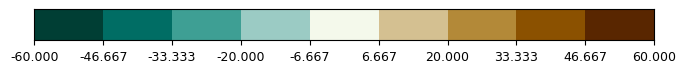


For ['GWL11C_D2_timescale_3months', 'GWL15C_D2_timescale_3months', 'GWL20C_D2_timescale_3months', 'GWL25C_D2_timescale_3months'], use:

Bin divisions: [-90.000, -70.000, -50.000, -30.000, -10.000, 10.000, 30.000, 50.000, 70.000, 90.000]
Bin centers: [-80.000, -60.000, -40.000, -20.000, 0.000, 20.000, 40.000, 60.000, 80.000]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


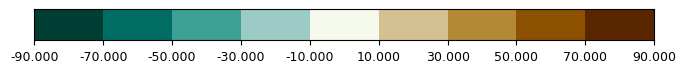


For ['GWL11C_D2_timescale_6months', 'GWL15C_D2_timescale_6months', 'GWL20C_D2_timescale_6months', 'GWL25C_D2_timescale_6months'], use:

Bin divisions: [-120.000, -93.333, -66.667, -40.000, -13.333, 13.333, 40.000, 66.667, 93.333, 120.000]
Bin centers: [-106.667, -80.000, -53.333, -26.667, 0.000, 26.667, 53.333, 80.000, 106.667]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


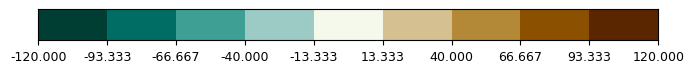


For ['GWL11C_D2_timescale_12months', 'GWL15C_D2_timescale_12months', 'GWL20C_D2_timescale_12months', 'GWL25C_D2_timescale_12months'], use:

Bin divisions: [-150.000, -116.667, -83.333, -50.000, -16.667, 16.667, 50.000, 83.333, 116.667, 150.000]
Bin centers: [-133.333, -100.000, -66.667, -33.333, 0.000, 33.333, 66.667, 100.000, 133.333]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


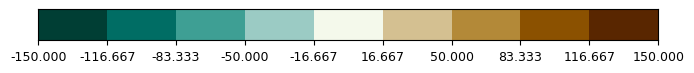


For ['GWL11C_D2_timescale_24months', 'GWL15C_D2_timescale_24months', 'GWL20C_D2_timescale_24months', 'GWL25C_D2_timescale_24months'], use:

Bin divisions: [-240.000, -186.667, -133.333, -80.000, -26.667, 26.667, 80.000, 133.333, 186.667, 240.000]
Bin centers: [-213.333, -160.000, -106.667, -53.333, 0.000, 53.333, 106.667, 160.000, 213.333]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


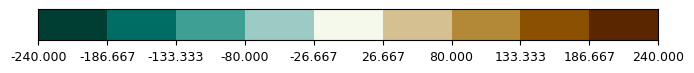


For ['GWL11C_D3_timescale_1months', 'GWL15C_D3_timescale_1months', 'GWL20C_D3_timescale_1months', 'GWL25C_D3_timescale_1months'], use:

Bin divisions: [-90.000, -70.000, -50.000, -30.000, -10.000, 10.000, 30.000, 50.000, 70.000, 90.000]
Bin centers: [-80.000, -60.000, -40.000, -20.000, 0.000, 20.000, 40.000, 60.000, 80.000]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


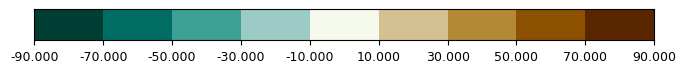


For ['GWL11C_D3_timescale_3months', 'GWL15C_D3_timescale_3months', 'GWL20C_D3_timescale_3months', 'GWL25C_D3_timescale_3months'], use:

Bin divisions: [-140.000, -108.889, -77.778, -46.667, -15.556, 15.556, 46.667, 77.778, 108.889, 140.000]
Bin centers: [-124.444, -93.333, -62.222, -31.111, -0.000, 31.111, 62.222, 93.333, 124.444]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


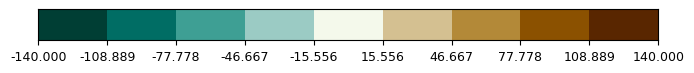


For ['GWL11C_D3_timescale_6months', 'GWL15C_D3_timescale_6months', 'GWL20C_D3_timescale_6months', 'GWL25C_D3_timescale_6months'], use:

Bin divisions: [-180.000, -140.000, -100.000, -60.000, -20.000, 20.000, 60.000, 100.000, 140.000, 180.000]
Bin centers: [-160.000, -120.000, -80.000, -40.000, 0.000, 40.000, 80.000, 120.000, 160.000]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


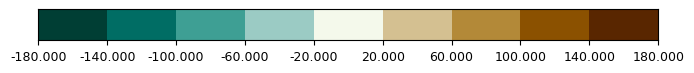


For ['GWL11C_D3_timescale_12months', 'GWL15C_D3_timescale_12months', 'GWL20C_D3_timescale_12months', 'GWL25C_D3_timescale_12months'], use:

Bin divisions: [-220.000, -171.111, -122.222, -73.333, -24.444, 24.444, 73.333, 122.222, 171.111, 220.000]
Bin centers: [-195.556, -146.667, -97.778, -48.889, -0.000, 48.889, 97.778, 146.667, 195.556]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


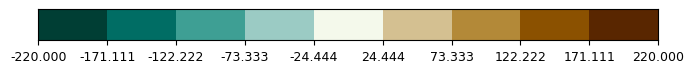


For ['GWL11C_D3_timescale_24months', 'GWL15C_D3_timescale_24months', 'GWL20C_D3_timescale_24months', 'GWL25C_D3_timescale_24months'], use:

Bin divisions: [-360.000, -280.000, -200.000, -120.000, -40.000, 40.000, 120.000, 200.000, 280.000, 360.000]
Bin centers: [-320.000, -240.000, -160.000, -80.000, 0.000, 80.000, 160.000, 240.000, 320.000]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


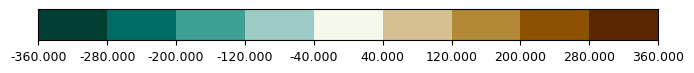


For ['GWL11C_D4_timescale_1months', 'GWL15C_D4_timescale_1months', 'GWL20C_D4_timescale_1months', 'GWL25C_D4_timescale_1months'], use:

Bin divisions: [-200.000, -155.556, -111.111, -66.667, -22.222, 22.222, 66.667, 111.111, 155.556, 200.000]
Bin centers: [-177.778, -133.333, -88.889, -44.444, 0.000, 44.444, 88.889, 133.333, 177.778]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


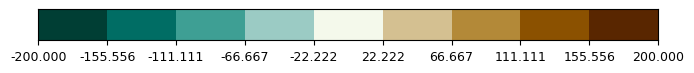


For ['GWL11C_D4_timescale_3months', 'GWL15C_D4_timescale_3months', 'GWL20C_D4_timescale_3months', 'GWL25C_D4_timescale_3months'], use:

Bin divisions: [-220.000, -171.111, -122.222, -73.333, -24.444, 24.444, 73.333, 122.222, 171.111, 220.000]
Bin centers: [-195.556, -146.667, -97.778, -48.889, -0.000, 48.889, 97.778, 146.667, 195.556]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


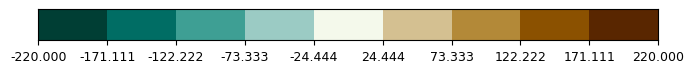


For ['GWL11C_D4_timescale_6months', 'GWL15C_D4_timescale_6months', 'GWL20C_D4_timescale_6months', 'GWL25C_D4_timescale_6months'], use:

Bin divisions: [-280.000, -217.778, -155.556, -93.333, -31.111, 31.111, 93.333, 155.556, 217.778, 280.000]
Bin centers: [-248.889, -186.667, -124.444, -62.222, -0.000, 62.222, 124.444, 186.667, 248.889]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


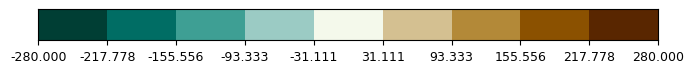


For ['GWL11C_D4_timescale_12months', 'GWL15C_D4_timescale_12months', 'GWL20C_D4_timescale_12months', 'GWL25C_D4_timescale_12months'], use:

Bin divisions: [-360.000, -280.000, -200.000, -120.000, -40.000, 40.000, 120.000, 200.000, 280.000, 360.000]
Bin centers: [-320.000, -240.000, -160.000, -80.000, 0.000, 80.000, 160.000, 240.000, 320.000]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


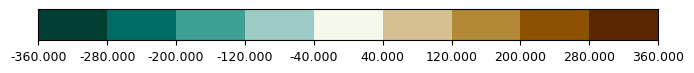


For ['GWL11C_D4_timescale_24months', 'GWL15C_D4_timescale_24months', 'GWL20C_D4_timescale_24months', 'GWL25C_D4_timescale_24months'], use:

Bin divisions: [-640.000, -497.778, -355.556, -213.333, -71.111, 71.111, 213.333, 355.556, 497.778, 640.000]
Bin centers: [-568.889, -426.667, -284.444, -142.222, 0.000, 142.222, 284.444, 426.667, 568.889]
Colors: ["#003E34", "#006D64", "#3E9F94", "#9BCBC4", "#F4F9EB", "#D4C091", "#B38938", "#8B5100", "#592600"]


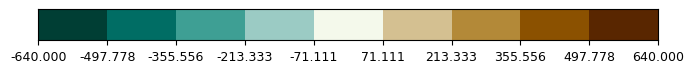




precip_accum

For ['ctrl_199707', 'ctrl_199904_19990428_12Z_to_19990429_12Z', 'ctrl_199904_19990429_12Z_to_19990430_12Z', 'ctrl_199904_19990430_12Z_to_19990501_12Z', 'ctrl_201309_20130909_12Z_to_20130910_12Z', 'ctrl_201309_20130910_12Z_to_20130911_12Z', 'ctrl_201309_20130911_12Z_to_20130912_12Z', 'ctrl_201309_20130912_12Z_to_20130913_12Z', 'ctrl_201309_20130913_12Z_to_20130914_12Z', 'ctrl_201309_20130914_12Z_to_20130915_12Z', 'ctrl_201309_7day', 'ctrl_202107', 'pgw_199707', 'pgw_199904_19990428_12Z_to_19990429_12Z', 'pgw_199904_19990429_12Z_to_19990430_12Z', 'pgw_199904_19990430_12Z_to_19990501_12Z', 'pgw_201309_20130909_12Z_to_20130910_12Z', 'pgw_201309_20130910_12Z_to_20130911_12Z', 'pgw_201309_20130911_12Z_to_20130912_12Z', 'pgw_201309_20130912_12Z_to_20130913_12Z', 'pgw_201309_20130913_12Z_to_20130914_12Z', 'pgw_201309_20130914_12Z_to_20130915_12Z', 'pgw_201309_7day', 'pgw_202107'], use:

Bin divisions: [0.000, 25.000, 50.000, 75.000, 100.000, 125.000, 150.000, 175.000, 200.000,

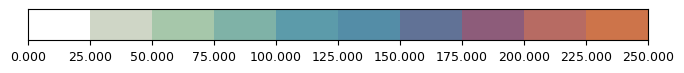




Qice
====

For ['mean_CTL_MAMJJAS', 'mean_PGW_MAMJJAS'], use:

Bin divisions: [0.000, 0.018, 0.036, 0.054, 0.072, 0.090, 0.108, 0.126, 0.144, 0.162, 0.180]
Bin centers: [0.009, 0.027, 0.045, 0.063, 0.081, 0.099, 0.117, 0.135, 0.153, 0.171]
Colors: ["#E5F4BE", "#AEE2A9", "#78CEA3", "#5AB6A4", "#4D9BA1", "#44829B", "#3E6896", "#404C8B", "#3E3666", "#30233D"]


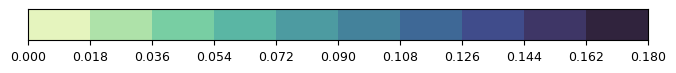


For ['diff_PGW_minus_CTL_MAMJJAS'], use:

Bin divisions: [-10.000, -7.778, -5.556, -3.333, -1.111, 1.111, 3.333, 5.556, 7.778, 10.000]
Bin centers: [-8.889, -6.667, -4.444, -2.222, 0.000, 2.222, 4.444, 6.667, 8.889]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


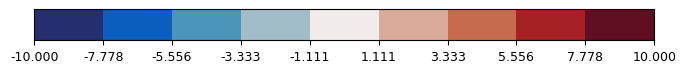




R95p
====

For ['GWL11C_minus_REF_absoule_change', 'GWL15C_minus_REF_absoule_change', 'GWL20C_minus_REF_absoule_change', 'GWL25C_minus_REF_absoule_change'], use:

Bin divisions: [-30.000, -23.333, -16.667, -10.000, -3.333, 3.333, 10.000, 16.667, 23.333, 30.000]
Bin centers: [-26.667, -20.000, -13.333, -6.667, 0.000, 6.667, 13.333, 20.000, 26.667]
Colors: ["#592600", "#8B5100", "#B38938", "#D4C091", "#F3F9EC", "#9BCBC4", "#3E9F94", "#006D64", "#003E34"]


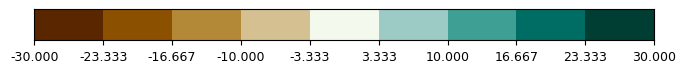


For ['GWL11C_minus_REF_relative_change', 'GWL15C_minus_REF_relative_change', 'GWL20C_minus_REF_relative_change', 'GWL25C_minus_REF_relative_change'], use:

Bin divisions: [-30.000, -23.333, -16.667, -10.000, -3.333, 3.333, 10.000, 16.667, 23.333, 30.000]
Bin centers: [-26.667, -20.000, -13.333, -6.667, 0.000, 6.667, 13.333, 20.000, 26.667]
Colors: ["#592600", "#8B5100", "#B38938", "#D4C091", "#F3F9EC", "#9BCBC4", "#3E9F94", "#006D64", "#003E34"]


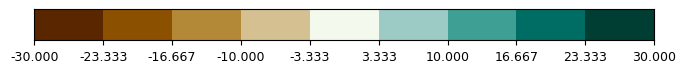


For ['GWL11C_actual_values', 'GWL15C_actual_values', 'GWL20C_actual_values', 'GWL25C_actual_values', 'REF_actual_values'], use:

Bin divisions: [40.000, 66.000, 92.000, 118.000, 144.000, 170.000, 196.000, 222.000, 248.000, 274.000, 300.000]
Bin centers: [53.000, 79.000, 105.000, 131.000, 157.000, 183.000, 209.000, 235.000, 261.000, 287.000]
Colors: ["#E5F5EB", "#B8E5D0", "#79D5BD", "#32C3B1", "#00ABA7", "#13949C", "#267B8D", "#31637A", "#334D65", "#2E394F"]


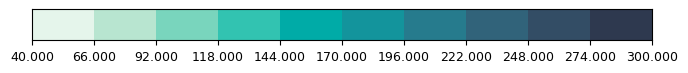




refl_diff

For ['apr-sep_freq0_10', 'apr-sep_freq10_20', 'JA_freq0_10', 'JA_freq10_20', 'MJ_freq0_10', 'MJ_freq10_20'], use:

Bin divisions: [-32.000, -24.889, -17.778, -10.667, -3.556, 3.556, 10.667, 17.778, 24.889, 32.000]
Bin centers: [-28.444, -21.333, -14.222, -7.111, 0.000, 7.111, 14.222, 21.333, 28.444]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


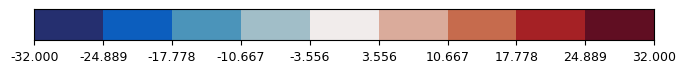


For ['apr-sep_freq20_30', 'apr-sep_freq30_40', 'JA_freq20_30', 'JA_freq30_40', 'MJ_freq20_30', 'MJ_freq30_40'], use:

Bin divisions: [-12.000, -9.333, -6.667, -4.000, -1.333, 1.333, 4.000, 6.667, 9.333, 12.000]
Bin centers: [-10.667, -8.000, -5.333, -2.667, -0.000, 2.667, 5.333, 8.000, 10.667]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


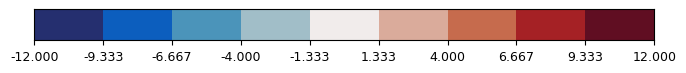


For ['apr-sep_freq40_50', 'apr-sep_freq50plus', 'JA_freq40_50', 'JA_freq50plus', 'MJ_freq40_50', 'MJ_freq50plus'], use:

Bin divisions: [-6.000, -4.667, -3.333, -2.000, -0.667, 0.667, 2.000, 3.333, 4.667, 6.000]
Bin centers: [-5.333, -4.000, -2.667, -1.333, -0.000, 1.333, 2.667, 4.000, 5.333]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


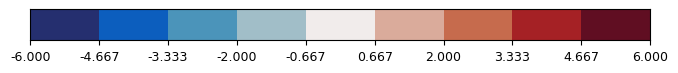




rlo
===

For ['10m_GWL20C_SON_actual_values', '10m_GWL20C_DJF_actual_values', '10m_GWL20C_MAM_actual_values', '10m_GWL20C_JJA_actual_values', '10m_GWL20C_ANN_actual_values', '10m_GWL11C_SON_actual_values', '10m_GWL11C_DJF_actual_values', '10m_GWL11C_MAM_actual_values', '10m_GWL11C_JJA_actual_values', '10m_GWL11C_ANN_actual_values', '10m_GWL15C_SON_actual_values', '10m_GWL15C_DJF_actual_values', '10m_GWL15C_MAM_actual_values', '10m_GWL15C_JJA_actual_values', '10m_GWL15C_ANN_actual_values', '10m_hist_SON_actual_values', '10m_hist_DJF_actual_values', '10m_hist_MAM_actual_values', '10m_hist_JJA_actual_values', '10m_hist_ANN_actual_values', '10m_GWL25C_SON_actual_values', '10m_GWL25C_DJF_actual_values', '10m_GWL25C_MAM_actual_values', '10m_GWL25C_JJA_actual_values', '10m_GWL25C_ANN_actual_values', '100m_GWL25C_SON_actual_values', '100m_GWL25C_DJF_actual_values', '100m_GWL25C_MAM_actual_values', '100m_GWL25C_JJA_actual_values', '100m_GWL25C_ANN_actual_values', '100m_hist_SON_actual_values

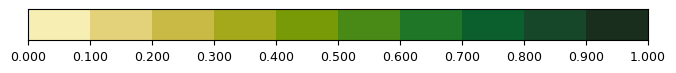


For ['GWL11C_ANN_absolute_change', 'GWL15C_ANN_absolute_change', 'GWL20C_ANN_absolute_change', 'GWL25C_ANN_absolute_change'], use:

Bin divisions: [-0.060, -0.047, -0.033, -0.020, -0.007, 0.007, 0.020, 0.033, 0.047, 0.060]
Bin centers: [-0.053, -0.040, -0.027, -0.013, 0.000, 0.013, 0.027, 0.040, 0.053]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


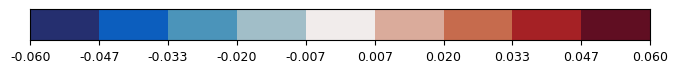




Rx1day

For ['GWL11C_minus_REF_absoule_change', 'GWL15C_minus_REF_absoule_change', 'GWL20C_minus_REF_absoule_change', 'GWL25C_minus_REF_absoule_change'], use:

Bin divisions: [-10.000, -7.778, -5.556, -3.333, -1.111, 1.111, 3.333, 5.556, 7.778, 10.000]
Bin centers: [-8.889, -6.667, -4.444, -2.222, 0.000, 2.222, 4.444, 6.667, 8.889]
Colors: ["#592600", "#8B5100", "#B38938", "#D4C091", "#F3F9EC", "#9BCBC4", "#3E9F94", "#006D64", "#003E34"]


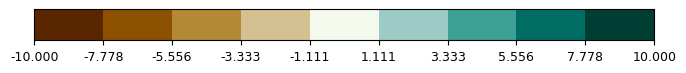


For ['GWL11C_minus_REF_relative_change', 'GWL15C_minus_REF_relative_change', 'GWL20C_minus_REF_relative_change', 'GWL25C_minus_REF_relative_change'], use:

Bin divisions: [-20.000, -15.556, -11.111, -6.667, -2.222, 2.222, 6.667, 11.111, 15.556, 20.000]
Bin centers: [-17.778, -13.333, -8.889, -4.444, 0.000, 4.444, 8.889, 13.333, 17.778]
Colors: ["#592600", "#8B5100", "#B38938", "#D4C091", "#F3F9EC", "#9BCBC4", "#3E9F94", "#006D64", "#003E34"]


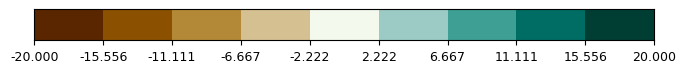


For ['GWL11C_actual_values', 'GWL15C_actual_values', 'GWL20C_actual_values', 'GWL25C_actual_values', 'REF_actual_values'], use:

Bin divisions: [15.000, 21.500, 28.000, 34.500, 41.000, 47.500, 54.000, 60.500, 67.000, 73.500, 80.000]
Bin centers: [18.250, 24.750, 31.250, 37.750, 44.250, 50.750, 57.250, 63.750, 70.250, 76.750]
Colors: ["#E5F5EB", "#B8E5D0", "#79D5BD", "#32C3B1", "#00ABA7", "#13949C", "#267B8D", "#31637A", "#334D65", "#2E394F"]


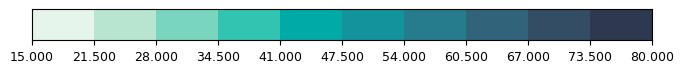




Rx1hour

For ['GWL11C_minus_REF_absoule_change', 'GWL15C_minus_REF_absoule_change', 'GWL20C_minus_REF_absoule_change', 'GWL25C_minus_REF_absoule_change'], use:

Bin divisions: [-5.000, -3.889, -2.778, -1.667, -0.556, 0.556, 1.667, 2.778, 3.889, 5.000]
Bin centers: [-4.444, -3.333, -2.222, -1.111, 0.000, 1.111, 2.222, 3.333, 4.444]
Colors: ["#592600", "#8B5100", "#B38938", "#D4C091", "#F3F9EC", "#9BCBC4", "#3E9F94", "#006D64", "#003E34"]


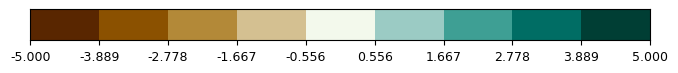


For ['GWL11C_minus_REF_relative_change', 'GWL15C_minus_REF_relative_change', 'GWL20C_minus_REF_relative_change', 'GWL25C_minus_REF_relative_change'], use:

Bin divisions: [-30.000, -23.333, -16.667, -10.000, -3.333, 3.333, 10.000, 16.667, 23.333, 30.000]
Bin centers: [-26.667, -20.000, -13.333, -6.667, 0.000, 6.667, 13.333, 20.000, 26.667]
Colors: ["#592600", "#8B5100", "#B38938", "#D4C091", "#F3F9EC", "#9BCBC4", "#3E9F94", "#006D64", "#003E34"]


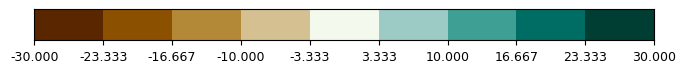


For ['GWL11C_actual_values', 'GWL15C_actual_values', 'GWL20C_actual_values', 'GWL25C_actual_values', 'REF_actual_values'], use:

Bin divisions: [3.000, 5.000, 7.000, 9.000, 11.000, 13.000, 15.000, 17.000, 19.000, 21.000, 23.000]
Bin centers: [4.000, 6.000, 8.000, 10.000, 12.000, 14.000, 16.000, 18.000, 20.000, 22.000]
Colors: ["#E5F5EB", "#B8E5D0", "#79D5BD", "#32C3B1", "#00ABA7", "#13949C", "#267B8D", "#31637A", "#334D65", "#2E394F"]


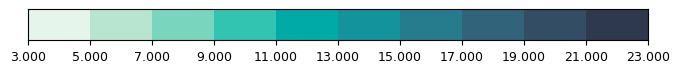




Rx5day

For ['GWL11C_minus_REF_absoule_change', 'GWL15C_minus_REF_absoule_change', 'GWL20C_minus_REF_absoule_change', 'GWL25C_minus_REF_absoule_change'], use:

Bin divisions: [-20.000, -15.556, -11.111, -6.667, -2.222, 2.222, 6.667, 11.111, 15.556, 20.000]
Bin centers: [-17.778, -13.333, -8.889, -4.444, 0.000, 4.444, 8.889, 13.333, 17.778]
Colors: ["#592600", "#8B5100", "#B38938", "#D4C091", "#F3F9EC", "#9BCBC4", "#3E9F94", "#006D64", "#003E34"]


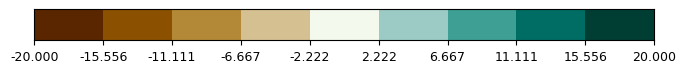


For ['GWL11C_minus_REF_relative_change', 'GWL15C_minus_REF_relative_change', 'GWL20C_minus_REF_relative_change', 'GWL25C_minus_REF_relative_change'], use:

Bin divisions: [-15.000, -11.667, -8.333, -5.000, -1.667, 1.667, 5.000, 8.333, 11.667, 15.000]
Bin centers: [-13.333, -10.000, -6.667, -3.333, 0.000, 3.333, 6.667, 10.000, 13.333]
Colors: ["#592600", "#8B5100", "#B38938", "#D4C091", "#F3F9EC", "#9BCBC4", "#3E9F94", "#006D64", "#003E34"]


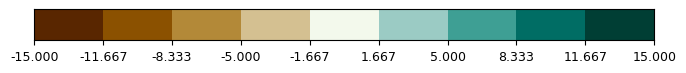


For ['GWL11C_actual_values', 'GWL15C_actual_values', 'GWL20C_actual_values', 'GWL25C_actual_values', 'REF_actual_values'], use:

Bin divisions: [25.000, 37.500, 50.000, 62.500, 75.000, 87.500, 100.000, 112.500, 125.000, 137.500, 150.000]
Bin centers: [31.250, 43.750, 56.250, 68.750, 81.250, 93.750, 106.250, 118.750, 131.250, 143.750]
Colors: ["#E5F5EB", "#B8E5D0", "#79D5BD", "#32C3B1", "#00ABA7", "#13949C", "#267B8D", "#31637A", "#334D65", "#2E394F"]


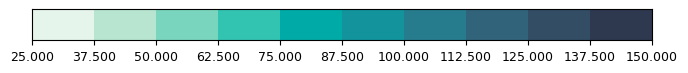




RZSM
====

For ['REF'], use:

Bin divisions: [0.100, 0.115, 0.130, 0.145, 0.160, 0.175, 0.190, 0.205, 0.220, 0.235, 0.250]
Bin centers: [0.108, 0.122, 0.138, 0.153, 0.167, 0.182, 0.198, 0.213, 0.228, 0.242]
Colors: ["#EEEAE2", "#C9D4BF", "#A1C1A1", "#76B08D", "#439E82", "#19897D", "#137174", "#1B5867", "#1C4259", "#18294A"]


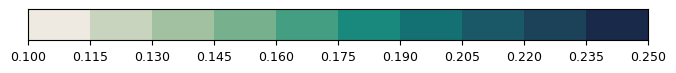




snow_fraction

For ['absolute_apr', 'absolute_dec', 'absolute_feb', 'absolute_jan', 'absolute_mar', 'absolute_nov', 'absolute_oct', 'absolute_sep'], use:

Bin divisions: [-25.000, -19.444, -13.889, -8.333, -2.778, 2.778, 8.333, 13.889, 19.444, 25.000]
Bin centers: [-22.222, -16.667, -11.111, -5.556, 0.000, 5.556, 11.111, 16.667, 22.222]
Colors: ["#592600", "#8B5100", "#B38938", "#D4C091", "#F3F9EC", "#9BCBC4", "#3E9F94", "#006D64", "#003E34"]


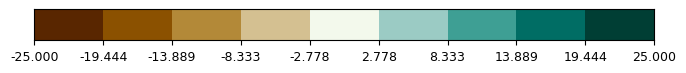


For ['relative_apr', 'relative_dec', 'relative_feb', 'relative_jan', 'relative_mar', 'relative_nov', 'relative_oct', 'relative_sep'], use:

Bin divisions: [-100.000, -77.778, -55.556, -33.333, -11.111, 11.111, 33.333, 55.556, 77.778, 100.000]
Bin centers: [-88.889, -66.667, -44.444, -22.222, 0.000, 22.222, 44.444, 66.667, 88.889]
Colors: ["#592600", "#8B5100", "#B38938", "#D4C091", "#F3F9EC", "#9BCBC4", "#3E9F94", "#006D64", "#003E34"]


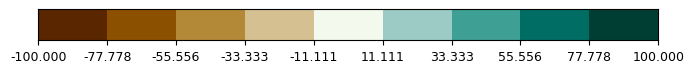




SSR
===

For ['hist_actual_values', 'GWL11C_actual_values', 'GWL15C_actual_values', 'GWL20C_actual_values', 'GWL25C_actual_values'], use:

Bin divisions: [0.000, 12.000, 24.000, 36.000, 48.000, 60.000, 72.000, 84.000, 96.000, 108.000, 120.000]
Bin centers: [6.000, 18.000, 30.000, 42.000, 54.000, 66.000, 78.000, 90.000, 102.000, 114.000]
Colors: ["#FAEDD7", "#EED3BC", "#E6B8A6", "#E19C99", "#DC7A95", "#D15A98", "#B74199", "#923593", "#6A2F88", "#3E2976"]


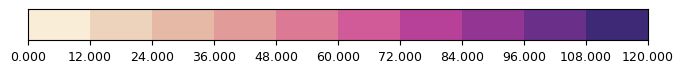




SWE_change

For ['GWL_1.1', 'GWL_1.5', 'GWL_2.0', 'GWL_2.5', 'GWL_3.0'], use:

Bin divisions: [-100.000, -88.889, -77.778, -66.667, -55.556, -44.444, -33.333, -22.222, -11.111, 0.000]
Bin centers: [-94.444, -83.333, -72.222, -61.111, -50.000, -38.889, -27.778, -16.667, -5.556]
Colors: ["#4E0D1A", "#730E27", "#981527", "#B13425", "#C0593C", "#CB7A60", "#D59A87", "#DFBCB0", "#EADCD9"]


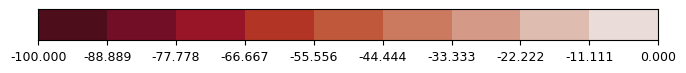




SWE_peak_mm

For ['historical', 'GWL_1.5', 'GWL_1.1', 'GWL_3.0', 'GWL_2.5', 'GWL_2.0'], use:

Bin divisions: [0.000, 100.000, 200.000, 300.000, 400.000, 500.000, 600.000, 700.000, 800.000, 900.000, 1000.000]
Bin centers: [50.000, 150.000, 250.000, 350.000, 450.000, 550.000, 650.000, 750.000, 850.000, 950.000]
Colors: ["#D5F0F2", "#A4D7DD", "#79BED0", "#5EA3C6", "#4988BC", "#3F6CB2", "#3F509B", "#383873", "#26254A", "#0F1024"]


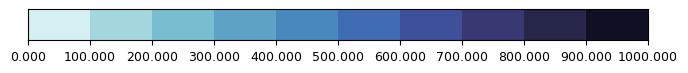




TotPpt

For ['GWL11C_minus_REF_absoule_change', 'GWL15C_minus_REF_absoule_change', 'GWL20C_minus_REF_absoule_change', 'GWL25C_minus_REF_absoule_change'], use:

Bin divisions: [-140.000, -108.889, -77.778, -46.667, -15.556, 15.556, 46.667, 77.778, 108.889, 140.000]
Bin centers: [-124.444, -93.333, -62.222, -31.111, -0.000, 31.111, 62.222, 93.333, 124.444]
Colors: ["#592600", "#8B5100", "#B38938", "#D4C091", "#F3F9EC", "#9BCBC4", "#3E9F94", "#006D64", "#003E34"]


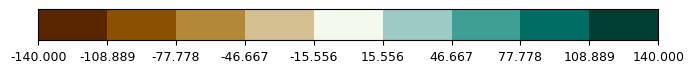


For ['GWL11C_minus_REF_relative_change', 'GWL15C_minus_REF_relative_change', 'GWL20C_minus_REF_relative_change', 'GWL25C_minus_REF_relative_change'], use:

Bin divisions: [-12.000, -9.333, -6.667, -4.000, -1.333, 1.333, 4.000, 6.667, 9.333, 12.000]
Bin centers: [-10.667, -8.000, -5.333, -2.667, -0.000, 2.667, 5.333, 8.000, 10.667]
Colors: ["#592600", "#8B5100", "#B38938", "#D4C091", "#F3F9EC", "#9BCBC4", "#3E9F94", "#006D64", "#003E34"]


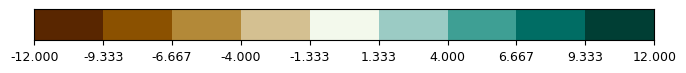


For ['GWL11C_actual_values', 'GWL15C_actual_values', 'GWL20C_actual_values', 'GWL25C_actual_values', 'REF_actual_values'], use:

Bin divisions: [200.000, 330.000, 460.000, 590.000, 720.000, 850.000, 980.000, 1110.000, 1240.000, 1370.000, 1500.000]
Bin centers: [265.000, 395.000, 525.000, 655.000, 785.000, 915.000, 1045.000, 1175.000, 1305.000, 1435.000]
Colors: ["#E5F5EB", "#B8E5D0", "#79D5BD", "#32C3B1", "#00ABA7", "#13949C", "#267B8D", "#31637A", "#334D65", "#2E394F"]


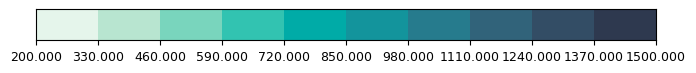




TX90F
=====

For ['GWL11C_minus_REF_absoule_change', 'GWL15C_minus_REF_absoule_change', 'GWL20C_minus_REF_absoule_change', 'GWL25C_minus_REF_absoule_change'], use:

Bin divisions: [0.000, 4.500, 9.000, 13.500, 18.000, 22.500, 27.000, 31.500, 36.000, 40.500, 45.000]
Bin centers: [2.250, 6.750, 11.250, 15.750, 20.250, 24.750, 29.250, 33.750, 38.250, 42.750]
Colors: ["#EBDFDC", "#E0C0B6", "#D7A291", "#CF866D", "#C5684A", "#BA492F", "#AA2724", "#8E1029", "#6D0E26", "#4B0C19"]


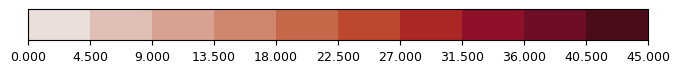


For ['GWL11C_actual_values', 'GWL15C_actual_values', 'GWL20C_actual_values', 'GWL25C_actual_values', 'REF_actual_values'], use:

Bin divisions: [0.000, 12.000, 24.000, 36.000, 48.000, 60.000, 72.000, 84.000, 96.000, 108.000, 120.000]
Bin centers: [6.000, 18.000, 30.000, 42.000, 54.000, 66.000, 78.000, 90.000, 102.000, 114.000]
Colors: ["#F4F3F2", "#DDDAD2", "#C8C2AC", "#B7A988", "#AA8E6B", "#9E745A", "#90584A", "#813D38", "#6E2524", "#580B0F"]


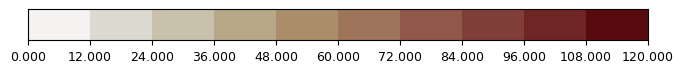




TX95F
=====

For ['GWL11C_minus_REF_absoule_change', 'GWL15C_minus_REF_absoule_change', 'GWL20C_minus_REF_absoule_change', 'GWL25C_minus_REF_absoule_change'], use:

Bin divisions: [0.000, 4.500, 9.000, 13.500, 18.000, 22.500, 27.000, 31.500, 36.000, 40.500, 45.000]
Bin centers: [2.250, 6.750, 11.250, 15.750, 20.250, 24.750, 29.250, 33.750, 38.250, 42.750]
Colors: ["#EBDFDC", "#E0C0B6", "#D7A291", "#CF866D", "#C5684A", "#BA492F", "#AA2724", "#8E1029", "#6D0E26", "#4B0C19"]


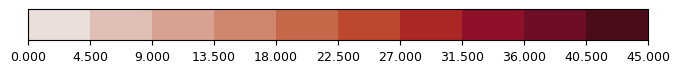


For ['GWL11C_actual_values', 'GWL15C_actual_values', 'GWL20C_actual_values', 'GWL25C_actual_values', 'REF_actual_values'], use:

Bin divisions: [0.000, 8.000, 16.000, 24.000, 32.000, 40.000, 48.000, 56.000, 64.000, 72.000, 80.000]
Bin centers: [4.000, 12.000, 20.000, 28.000, 36.000, 44.000, 52.000, 60.000, 68.000, 76.000]
Colors: ["#F4F3F2", "#DDDAD2", "#C8C2AC", "#B7A988", "#AA8E6B", "#9E745A", "#90584A", "#813D38", "#6E2524", "#580B0F"]


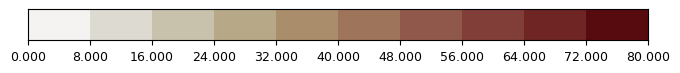




TX95p
=====

For ['GWL11C_minus_REF_absoule_change', 'GWL15C_minus_REF_absoule_change', 'GWL20C_minus_REF_absoule_change', 'GWL25C_minus_REF_absoule_change'], use:

Bin divisions: [5.000, 9.500, 14.000, 18.500, 23.000, 27.500, 32.000, 36.500, 41.000, 45.500, 50.000]
Bin centers: [7.250, 11.750, 16.250, 20.750, 25.250, 29.750, 34.250, 38.750, 43.250, 47.750]
Colors: ["#EBDFDC", "#E0C0B6", "#D7A291", "#CF866D", "#C5684A", "#BA492F", "#AA2724", "#8E1029", "#6D0E26", "#4B0C19"]


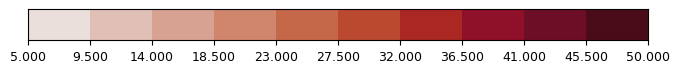


For ['GWL11C_actual_values', 'GWL15C_actual_values', 'GWL20C_actual_values', 'GWL25C_actual_values', 'REF_actual_values'], use:

Bin divisions: [15.000, 20.000, 25.000, 30.000, 35.000, 40.000, 45.000, 50.000, 55.000, 60.000, 65.000]
Bin centers: [17.500, 22.500, 27.500, 32.500, 37.500, 42.500, 47.500, 52.500, 57.500, 62.500]
Colors: ["#F4F3F2", "#DDDAD2", "#C8C2AC", "#B7A988", "#AA8E6B", "#9E745A", "#90584A", "#813D38", "#6E2524", "#580B0F"]


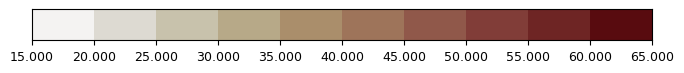




TxN5day

For ['GWL11C_minus_REF_absoule_change', 'GWL15C_minus_REF_absoule_change', 'GWL20C_minus_REF_absoule_change', 'GWL25C_minus_REF_absoule_change'], use:

Bin divisions: [1.000, 1.600, 2.200, 2.800, 3.400, 4.000, 4.600, 5.200, 5.800, 6.400, 7.000]
Bin centers: [1.300, 1.900, 2.500, 3.100, 3.700, 4.300, 4.900, 5.500, 6.100, 6.700]
Colors: ["#EBDFDC", "#E0C0B6", "#D7A291", "#CF866D", "#C5684A", "#BA492F", "#AA2724", "#8E1029", "#6D0E26", "#4B0C19"]


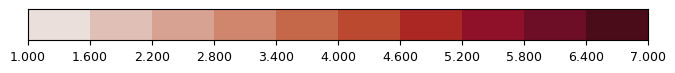


For ['GWL11C_actual_values', 'GWL15C_actual_values', 'GWL20C_actual_values', 'GWL25C_actual_values', 'REF_actual_values'], use:

Bin divisions: [45.000, 48.500, 52.000, 55.500, 59.000, 62.500, 66.000, 69.500, 73.000, 76.500, 80.000]
Bin centers: [46.750, 50.250, 53.750, 57.250, 60.750, 64.250, 67.750, 71.250, 74.750, 78.250]
Colors: ["#F4F3F2", "#DDDAD2", "#C8C2AC", "#B7A988", "#AA8E6B", "#9E745A", "#90584A", "#813D38", "#6E2524", "#580B0F"]


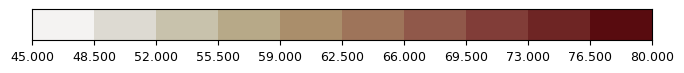




TxN65F

For ['GWL11C_minus_REF_absoule_change', 'GWL15C_minus_REF_absoule_change', 'GWL20C_minus_REF_absoule_change', 'GWL25C_minus_REF_absoule_change'], use:

Bin divisions: [0.000, 5.000, 10.000, 15.000, 20.000, 25.000, 30.000, 35.000, 40.000, 45.000, 50.000]
Bin centers: [2.500, 7.500, 12.500, 17.500, 22.500, 27.500, 32.500, 37.500, 42.500, 47.500]
Colors: ["#EBDFDC", "#E0C0B6", "#D7A291", "#CF866D", "#C5684A", "#BA492F", "#AA2724", "#8E1029", "#6D0E26", "#4B0C19"]


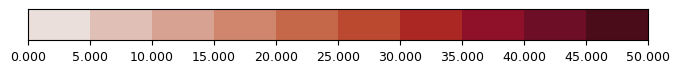


For ['GWL11C_actual_values', 'GWL15C_actual_values', 'GWL20C_actual_values', 'GWL25C_actual_values', 'REF_actual_values'], use:

Bin divisions: [0.000, 12.000, 24.000, 36.000, 48.000, 60.000, 72.000, 84.000, 96.000, 108.000, 120.000]
Bin centers: [6.000, 18.000, 30.000, 42.000, 54.000, 66.000, 78.000, 90.000, 102.000, 114.000]
Colors: ["#F4F3F2", "#DDDAD2", "#C8C2AC", "#B7A988", "#AA8E6B", "#9E745A", "#90584A", "#813D38", "#6E2524", "#580B0F"]


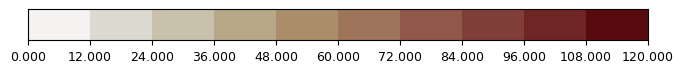




TxN80F

For ['GWL11C_minus_REF_absoule_change', 'GWL15C_minus_REF_absoule_change', 'GWL20C_minus_REF_absoule_change', 'GWL25C_minus_REF_absoule_change'], use:

Bin divisions: [0.000, 1.200, 2.400, 3.600, 4.800, 6.000, 7.200, 8.400, 9.600, 10.800, 12.000]
Bin centers: [0.600, 1.800, 3.000, 4.200, 5.400, 6.600, 7.800, 9.000, 10.200, 11.400]
Colors: ["#EBDFDC", "#E0C0B6", "#D7A291", "#CF866D", "#C5684A", "#BA492F", "#AA2724", "#8E1029", "#6D0E26", "#4B0C19"]


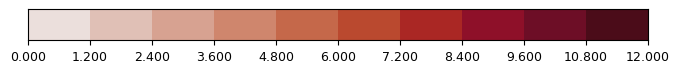


For ['GWL11C_actual_values', 'GWL15C_actual_values', 'GWL20C_actual_values', 'GWL25C_actual_values', 'REF_actual_values'], use:

Bin divisions: [0.000, 1.200, 2.400, 3.600, 4.800, 6.000, 7.200, 8.400, 9.600, 10.800, 12.000]
Bin centers: [0.600, 1.800, 3.000, 4.200, 5.400, 6.600, 7.800, 9.000, 10.200, 11.400]
Colors: ["#F4F3F2", "#DDDAD2", "#C8C2AC", "#B7A988", "#AA8E6B", "#9E745A", "#90584A", "#813D38", "#6E2524", "#580B0F"]


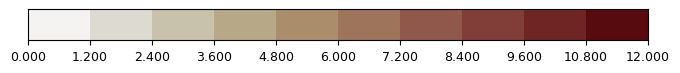




TxN95p

For ['GWL11C_minus_REF_absoule_change', 'GWL15C_minus_REF_absoule_change', 'GWL20C_minus_REF_absoule_change', 'GWL25C_minus_REF_absoule_change'], use:

Bin divisions: [10.000, 15.000, 20.000, 25.000, 30.000, 35.000, 40.000, 45.000, 50.000, 55.000, 60.000]
Bin centers: [12.500, 17.500, 22.500, 27.500, 32.500, 37.500, 42.500, 47.500, 52.500, 57.500]
Colors: ["#EBDFDC", "#E0C0B6", "#D7A291", "#CF866D", "#C5684A", "#BA492F", "#AA2724", "#8E1029", "#6D0E26", "#4B0C19"]


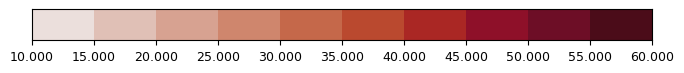


For ['GWL11C_actual_values', 'GWL15C_actual_values', 'GWL20C_actual_values', 'GWL25C_actual_values', 'REF_actual_values'], use:

Bin divisions: [15.000, 21.000, 27.000, 33.000, 39.000, 45.000, 51.000, 57.000, 63.000, 69.000, 75.000]
Bin centers: [18.000, 24.000, 30.000, 36.000, 42.000, 48.000, 54.000, 60.000, 66.000, 72.000]
Colors: ["#F4F3F2", "#DDDAD2", "#C8C2AC", "#B7A988", "#AA8E6B", "#9E745A", "#90584A", "#813D38", "#6E2524", "#580B0F"]


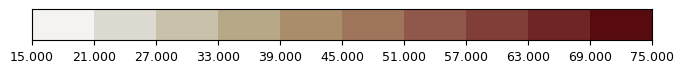




TxX5day

For ['GWL11C_minus_REF_absoule_change', 'GWL15C_minus_REF_absoule_change', 'GWL20C_minus_REF_absoule_change', 'GWL25C_minus_REF_absoule_change'], use:

Bin divisions: [1.000, 1.600, 2.200, 2.800, 3.400, 4.000, 4.600, 5.200, 5.800, 6.400, 7.000]
Bin centers: [1.300, 1.900, 2.500, 3.100, 3.700, 4.300, 4.900, 5.500, 6.100, 6.700]
Colors: ["#EBDFDC", "#E0C0B6", "#D7A291", "#CF866D", "#C5684A", "#BA492F", "#AA2724", "#8E1029", "#6D0E26", "#4B0C19"]


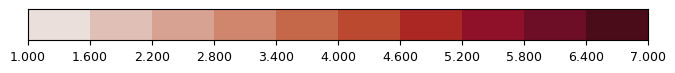


For ['GWL11C_actual_values', 'GWL15C_actual_values', 'GWL20C_actual_values', 'GWL25C_actual_values', 'REF_actual_values'], use:

Bin divisions: [60.000, 65.000, 70.000, 75.000, 80.000, 85.000, 90.000, 95.000, 100.000, 105.000, 110.000]
Bin centers: [62.500, 67.500, 72.500, 77.500, 82.500, 87.500, 92.500, 97.500, 102.500, 107.500]
Colors: ["#F4F3F2", "#DDDAD2", "#C8C2AC", "#B7A988", "#AA8E6B", "#9E745A", "#90584A", "#813D38", "#6E2524", "#580B0F"]


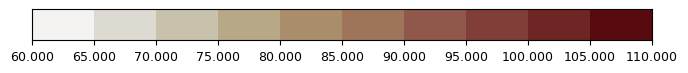




WBGTx80F

For ['GWL11C_minus_REF_absoule_change', 'GWL15C_minus_REF_absoule_change', 'GWL20C_minus_REF_absoule_change', 'GWL25C_minus_REF_absoule_change'], use:

Bin divisions: [0.000, 4.000, 8.000, 12.000, 16.000, 20.000, 24.000, 28.000, 32.000, 36.000, 40.000]
Bin centers: [2.000, 6.000, 10.000, 14.000, 18.000, 22.000, 26.000, 30.000, 34.000, 38.000]
Colors: ["#EBDFDC", "#E0C0B6", "#D7A291", "#CF866D", "#C5684A", "#BA492F", "#AA2724", "#8E1029", "#6D0E26", "#4B0C19"]


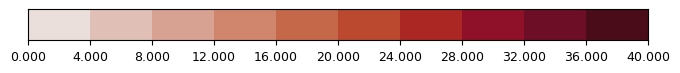


For ['GWL11C_actual_values', 'GWL15C_actual_values', 'GWL20C_actual_values', 'GWL25C_actual_values', 'REF_actual_values'], use:

Bin divisions: [0.000, 5.000, 10.000, 15.000, 20.000, 25.000, 30.000, 35.000, 40.000, 45.000, 50.000]
Bin centers: [2.500, 7.500, 12.500, 17.500, 22.500, 27.500, 32.500, 37.500, 42.500, 47.500]
Colors: ["#F4F3F2", "#DDDAD2", "#C8C2AC", "#B7A988", "#AA8E6B", "#9E745A", "#90584A", "#813D38", "#6E2524", "#580B0F"]


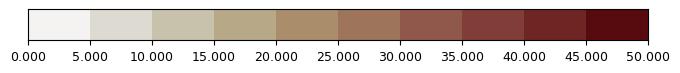




wind_drought_duration

For ['GWL20C_ANN_actual_values', 'GWL20C_SON_actual_values', 'GWL20C_DJF_actual_values', 'GWL20C_MAM_actual_values', 'GWL20C_JJA_actual_values', 'GWL25C_ANN_actual_values', 'GWL25C_SON_actual_values', 'GWL25C_DJF_actual_values', 'GWL25C_MAM_actual_values', 'GWL25C_JJA_actual_values', 'hist_ANN_actual_values', 'hist_SON_actual_values', 'hist_DJF_actual_values', 'hist_MAM_actual_values', 'hist_JJA_actual_values', 'GWL15C_ANN_actual_values', 'GWL15C_SON_actual_values', 'GWL15C_DJF_actual_values', 'GWL15C_MAM_actual_values', 'GWL15C_JJA_actual_values', 'GWL11C_ANN_actual_values', 'GWL11C_SON_actual_values', 'GWL11C_DJF_actual_values', 'GWL11C_MAM_actual_values', 'GWL11C_JJA_actual_values'], use:

Bin divisions: [4.000, 4.350, 4.700, 5.050, 5.400, 5.750, 6.100, 6.450, 6.800, 7.150, 7.500]
Bin centers: [4.175, 4.525, 4.875, 5.225, 5.575, 5.925, 6.275, 6.625, 6.975, 7.325]
Colors: ["#E2E89A", "#D5CA76", "#CAAE58", "#BD9345", "#AC7B3D", "#96673A", "#7D5538", "#624534"

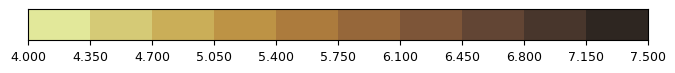


For ['GWL11C_ANN_absolute_change', 'GWL15C_ANN_absolute_change', 'GWL20C_ANN_absolute_change', 'GWL25C_ANN_absolute_change'], use:

Bin divisions: [-0.250, -0.194, -0.139, -0.083, -0.028, 0.028, 0.083, 0.139, 0.194, 0.250]
Bin centers: [-0.222, -0.167, -0.111, -0.056, 0.000, 0.056, 0.111, 0.167, 0.222]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


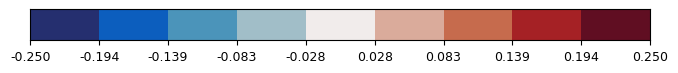




wind_drought_freq

For ['GWL20C_ANN_actual_values', 'GWL20C_SON_actual_values', 'GWL20C_DJF_actual_values', 'GWL20C_MAM_actual_values', 'GWL20C_JJA_actual_values', 'GWL25C_ANN_actual_values', 'GWL25C_SON_actual_values', 'GWL25C_DJF_actual_values', 'GWL25C_MAM_actual_values', 'GWL25C_JJA_actual_values', 'hist_ANN_actual_values', 'hist_SON_actual_values', 'hist_DJF_actual_values', 'hist_MAM_actual_values', 'hist_JJA_actual_values', 'GWL15C_ANN_actual_values', 'GWL15C_SON_actual_values', 'GWL15C_DJF_actual_values', 'GWL15C_MAM_actual_values', 'GWL15C_JJA_actual_values', 'GWL11C_ANN_actual_values', 'GWL11C_SON_actual_values', 'GWL11C_DJF_actual_values', 'GWL11C_MAM_actual_values', 'GWL11C_JJA_actual_values'], use:

Bin divisions: [0.000, 0.650, 1.300, 1.950, 2.600, 3.250, 3.900, 4.550, 5.200, 5.850, 6.500]
Bin centers: [0.325, 0.975, 1.625, 2.275, 2.925, 3.575, 4.225, 4.875, 5.525, 6.175]
Colors: ["#E2E89A", "#D5CA76", "#CAAE58", "#BD9345", "#AC7B3D", "#96673A", "#7D5538", "#624534", "#

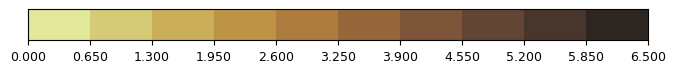


For ['GWL11C_ANN_absolute_change', 'GWL15C_ANN_absolute_change', 'GWL20C_ANN_absolute_change', 'GWL25C_ANN_absolute_change'], use:

Bin divisions: [-0.180, -0.140, -0.100, -0.060, -0.020, 0.020, 0.060, 0.100, 0.140, 0.180]
Bin centers: [-0.160, -0.120, -0.080, -0.040, 0.000, 0.040, 0.080, 0.120, 0.160]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


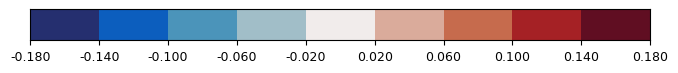




wpd
===

For ['10m_GWL20C_SON_actual_values', '10m_GWL20C_DJF_actual_values', '10m_GWL20C_MAM_actual_values', '10m_GWL20C_JJA_actual_values', '10m_GWL20C_ANN_actual_values', '10m_GWL11C_SON_actual_values', '10m_GWL11C_DJF_actual_values', '10m_GWL11C_MAM_actual_values', '10m_GWL11C_JJA_actual_values', '10m_GWL11C_ANN_actual_values', '10m_GWL15C_SON_actual_values', '10m_GWL15C_DJF_actual_values', '10m_GWL15C_MAM_actual_values', '10m_GWL15C_JJA_actual_values', '10m_GWL15C_ANN_actual_values', '10m_hist_SON_actual_values', '10m_hist_DJF_actual_values', '10m_hist_MAM_actual_values', '10m_hist_JJA_actual_values', '10m_hist_ANN_actual_values', '10m_GWL25C_SON_actual_values', '10m_GWL25C_DJF_actual_values', '10m_GWL25C_MAM_actual_values', '10m_GWL25C_JJA_actual_values', '10m_GWL25C_ANN_actual_values', '100m_GWL25C_SON_actual_values', '100m_GWL25C_DJF_actual_values', '100m_GWL25C_MAM_actual_values', '100m_GWL25C_JJA_actual_values', '100m_GWL25C_ANN_actual_values', '100m_hist_SON_actual_values

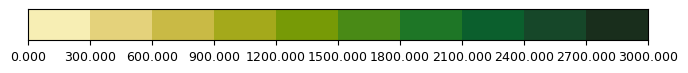


For ['GWL11C_ANN_absolute_change', 'GWL15C_ANN_absolute_change', 'GWL20C_ANN_absolute_change', 'GWL25C_ANN_absolute_change'], use:

Bin divisions: [-250.000, -194.444, -138.889, -83.333, -27.778, 27.778, 83.333, 138.889, 194.444, 250.000]
Bin centers: [-222.222, -166.667, -111.111, -55.556, 0.000, 55.556, 111.111, 166.667, 222.222]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


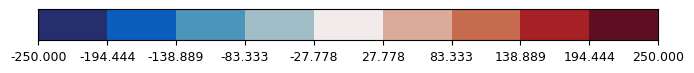




wspd
====

For ['10m_GWL20C_SON_actual_values', '10m_GWL20C_DJF_actual_values', '10m_GWL20C_MAM_actual_values', '10m_GWL20C_JJA_actual_values', '10m_GWL20C_ANN_actual_values', '10m_GWL11C_SON_actual_values', '10m_GWL11C_DJF_actual_values', '10m_GWL11C_MAM_actual_values', '10m_GWL11C_JJA_actual_values', '10m_GWL11C_ANN_actual_values', '10m_GWL15C_SON_actual_values', '10m_GWL15C_DJF_actual_values', '10m_GWL15C_MAM_actual_values', '10m_GWL15C_JJA_actual_values', '10m_GWL15C_ANN_actual_values', '10m_hist_SON_actual_values', '10m_hist_DJF_actual_values', '10m_hist_MAM_actual_values', '10m_hist_JJA_actual_values', '10m_hist_ANN_actual_values', '10m_GWL25C_SON_actual_values', '10m_GWL25C_DJF_actual_values', '10m_GWL25C_MAM_actual_values', '10m_GWL25C_JJA_actual_values', '10m_GWL25C_ANN_actual_values', '100m_GWL25C_SON_actual_values', '100m_GWL25C_DJF_actual_values', '100m_GWL25C_MAM_actual_values', '100m_GWL25C_JJA_actual_values', '100m_GWL25C_ANN_actual_values', '100m_hist_SON_actual_valu

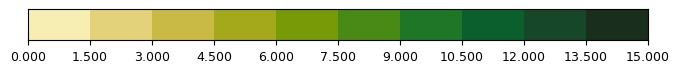


For ['100m_GWL20C_SON_relative_change', '100m_GWL20C_DJF_relative_change', '100m_GWL20C_MAM_relative_change', '100m_GWL20C_JJA_relative_change', '100m_GWL20C_ANN_relative_change', '100m_GWL25C_SON_relative_change', '100m_GWL25C_DJF_relative_change', '100m_GWL25C_MAM_relative_change', '100m_GWL25C_JJA_relative_change', '100m_GWL25C_ANN_relative_change', '10m_GWL11C_SON_relative_change', '10m_GWL11C_DJF_relative_change', '10m_GWL11C_MAM_relative_change', '10m_GWL11C_JJA_relative_change', '10m_GWL11C_ANN_relative_change', '10m_GWL20C_SON_relative_change', '10m_GWL20C_DJF_relative_change', '10m_GWL20C_MAM_relative_change', '10m_GWL20C_JJA_relative_change', '10m_GWL20C_ANN_relative_change', '100m_GWL15C_SON_relative_change', '100m_GWL15C_DJF_relative_change', '100m_GWL15C_MAM_relative_change', '100m_GWL15C_JJA_relative_change', '100m_GWL15C_ANN_relative_change', '100m_GWL11C_SON_relative_change', '100m_GWL11C_DJF_relative_change', '100m_GWL11C_MAM_relative_change', '100m_GWL11C_JJA_relativ

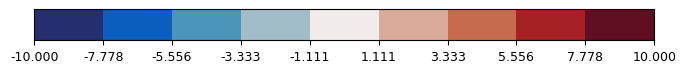


For ['GWL11C_ANN_absolute_change', 'GWL15C_ANN_absolute_change', 'GWL20C_ANN_absolute_change', 'GWL25C_ANN_absolute_change'], use:

Bin divisions: [-0.700, -0.544, -0.389, -0.233, -0.078, 0.078, 0.233, 0.389, 0.544, 0.700]
Bin centers: [-0.622, -0.467, -0.311, -0.156, 0.000, 0.156, 0.311, 0.467, 0.622]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


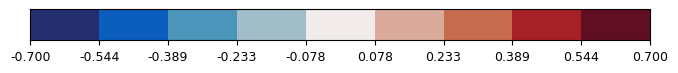




wspd10max_p95

For ['GWL11C_ANN_actual_values', 'GWL11C_SON_actual_values', 'GWL11C_DJF_actual_values', 'GWL11C_MAM_actual_values', 'GWL11C_JJA_actual_values', 'GWL15C_ANN_actual_values', 'GWL15C_SON_actual_values', 'GWL15C_DJF_actual_values', 'GWL15C_MAM_actual_values', 'GWL15C_JJA_actual_values', 'hist_ANN_actual_values', 'hist_SON_actual_values', 'hist_DJF_actual_values', 'hist_MAM_actual_values', 'hist_JJA_actual_values', 'GWL20C_ANN_actual_values', 'GWL20C_SON_actual_values', 'GWL20C_DJF_actual_values', 'GWL20C_MAM_actual_values', 'GWL20C_JJA_actual_values', 'GWL25C_ANN_actual_values', 'GWL25C_SON_actual_values', 'GWL25C_DJF_actual_values', 'GWL25C_MAM_actual_values', 'GWL25C_JJA_actual_values'], use:

Bin divisions: [5.000, 6.500, 8.000, 9.500, 11.000, 12.500, 14.000, 15.500, 17.000, 18.500, 20.000]
Bin centers: [5.750, 7.250, 8.750, 10.250, 11.750, 13.250, 14.750, 16.250, 17.750, 19.250]
Colors: ["#F7EEB4", "#E4D27B", "#C9BA45", "#A4A91B", "#779A06", "#498A16", "#1E7626", "#0

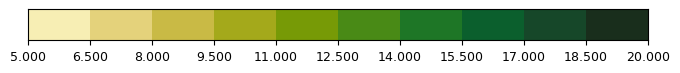


For ['GWL11C_ANN_absolute_change', 'GWL15C_ANN_absolute_change', 'GWL20C_ANN_absolute_change', 'GWL25C_ANN_absolute_change'], use:

Bin divisions: [-0.900, -0.700, -0.500, -0.300, -0.100, 0.100, 0.300, 0.500, 0.700, 0.900]
Bin centers: [-0.800, -0.600, -0.400, -0.200, 0.000, 0.200, 0.400, 0.600, 0.800]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


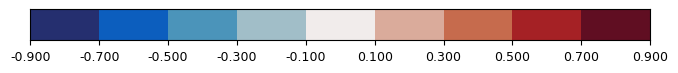




wspd10mean_p95

For ['GWL11C_ANN_actual_values', 'GWL11C_SON_actual_values', 'GWL11C_DJF_actual_values', 'GWL11C_MAM_actual_values', 'GWL11C_JJA_actual_values', 'GWL15C_ANN_actual_values', 'GWL15C_SON_actual_values', 'GWL15C_DJF_actual_values', 'GWL15C_MAM_actual_values', 'GWL15C_JJA_actual_values', 'hist_ANN_actual_values', 'hist_SON_actual_values', 'hist_DJF_actual_values', 'hist_MAM_actual_values', 'hist_JJA_actual_values', 'GWL20C_ANN_actual_values', 'GWL20C_SON_actual_values', 'GWL20C_DJF_actual_values', 'GWL20C_MAM_actual_values', 'GWL20C_JJA_actual_values', 'GWL25C_ANN_actual_values', 'GWL25C_SON_actual_values', 'GWL25C_DJF_actual_values', 'GWL25C_MAM_actual_values', 'GWL25C_JJA_actual_values'], use:

Bin divisions: [2.500, 4.250, 6.000, 7.750, 9.500, 11.250, 13.000, 14.750, 16.500, 18.250, 20.000]
Bin centers: [3.375, 5.125, 6.875, 8.625, 10.375, 12.125, 13.875, 15.625, 17.375, 19.125]
Colors: ["#F7EEB4", "#E4D27B", "#C9BA45", "#A4A91B", "#779A06", "#498A16", "#1E7626", "#0B

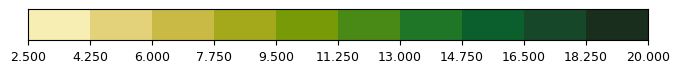


For ['GWL11C_ANN_absolute_change', 'GWL15C_ANN_absolute_change', 'GWL20C_ANN_absolute_change', 'GWL25C_ANN_absolute_change'], use:

Bin divisions: [-0.900, -0.700, -0.500, -0.300, -0.100, 0.100, 0.300, 0.500, 0.700, 0.900]
Bin centers: [-0.800, -0.600, -0.400, -0.200, 0.000, 0.200, 0.400, 0.600, 0.800]
Colors: ["#252F6F", "#0C5EBE", "#4B94BA", "#A1BEC8", "#F1ECEB", "#DAAB9B", "#C66B4D", "#A52125", "#600E22"]


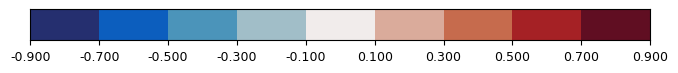

In [4]:
hazard_skip_list = ['ari_exceed','EFFIS']

for hazard_name in sorted(list(symbology_table['variable_group'].unique()), key=lambda s: s.lower()):
    if hazard_name in hazard_skip_list:
        continue
    rows = symbology_table[symbology_table['variable_group'] == hazard_name]
    print(hazard_name)
    print("=" * len(hazard_name))
    print()

    for _, row in rows.iterrows():
        # Parse out the bins and their colors
        vmin = float(row['symbology_min_value'])
        vmax = float(row['symbology_max_value'])
        nbins = (9 if vmin + vmax < 1e-3 else 10)
        bounds = np.linspace(vmin, vmax, nbins + 1)
        centers = (bounds[:-1] + bounds[1:]) / 2
        cmap = plt.get_cmap(row['symbology_colormap'])
        colors = [cmap((v - vmin) / (vmax - vmin)) for v in centers]
        
        # Print the values
        print(f"For {row['variable_subtype_list']}, use:\n")
        print("Bin divisions: [" + ", ".join((f"{v:0.3f}" for v in bounds)) + "]")
        print("Bin centers: [" + ", ".join((f"{v:0.3f}" for v in centers)) + "]")
        print("Colors: [" + ", ".join([f'"#{round(r * 255):02X}{round(g * 255):02X}{round(b * 255):02X}"' for r, g, b, _ in colors]) + "]")
        
        # Simple display of binned colorbar
        fig, ax = plt.subplots(figsize=(8, 0.4))
        x = np.linspace(vmin, vmax, 128)
        gradient = np.stack([x] * 8)
        ax.contourf(x, np.arange(8), gradient, colors=colors, levels=bounds)
        ax.set_xticks(bounds, [f"{v:0.3f}" for v in bounds], rotation=0, fontsize=9)
        ax.set_yticks([])
        plt.show()
        plt.close(fig)
        
        print()

    print("\n")